# Baseline de reconocimiento del abecedario — LSC70ANH

**Objetivo:** medir qué exactitud es alcanzable con landmarks de MediaPipe antes de
invertir en un pipeline propio. No es el modelo final.

**Cambios respecto a la versión anterior** (los tres eran bugs reales):

1. `validation_split` de Keras toma el **último** porcentaje del array **sin barajar**.
   Como los datos venían ordenados por clase, las últimas letras (W, X, Y, Z) caían
   enteras en validación y **nunca se entrenaban**. Eso produjo las cinco clases con
   recall exactamente 0.000. Aquí toda validación es explícita y separada por participante.
2. La clase `none` sólo existía para satisfacer un requisito de MediaPipe Model Maker,
   que ya no se usa. Son dígitos, y varios dígitos comparten configuración de mano con
   letras — generaba el 38 % de los errores. Se elimina.
3. La comparación frame vs temporal era injusta: comparaba exactitud por frame contra
   exactitud por toma. Aquí ambos enfoques se evalúan **por toma**, sobre las mismas tomas.

**Puntos de verificación manual** marcados con ⚠️ a lo largo del notebook.
4. Las features temporales se calculaban sobre landmarks ya normalizados, y la
   normalizacion pone la muneca en el origen en cada frame: borraba el movimiento
   de la mano antes de medirlo. Ahora se guardan tambien la posicion absoluta de
   la muneca y la escala, y se anaden 6 rasgos de trayectoria.

## 1. Configuración

In [1]:
# ============================================================
# CONFIGURACIÓN — todo lo editable vive aquí
# ============================================================

# --- Rutas ---
RUTA_ZIP_EN_DRIVE  = "/content/drive/MyDrive/LSC70/LSC70ANH.zip"
RUTA_EXTRACCION    = "/content/lsc_raw"     # disco local de Colab (rápido)
RUTA_DRIVE_DATASET = None                   # se autodetecta en la celda de descompresión
RUTA_TRABAJO       = "/content/lsc_work"    # dataset reorganizado
RUTA_SALIDA        = "/content/lsc_out"     # modelo exportado
RUTA_CACHE         = "/content/drive/MyDrive/LSC70/landmarks_cache.npz"

# --- Clases del abecedario ---
CLASES_ABECEDARIO = [
    "A","B","C","D","E","F","G","H","I","J","K","L","M",
    "N","NN","O","P","Q","R","S","T","U","V","W","X","Y","Z",
]
# "NN" = Ñ. Ajusta si el dataset usa otro nombre de carpeta.

# Los dígitos se copian a disco como 'none' por si luego quieres un rechazo explícito,
# pero se FILTRAN antes de entrenar. Model Maker exigía esa clase; nosotros no.
COPIAR_DIGITOS_COMO_NONE = True
MAX_IMGS_NONE            = 400
ENTRENAR_CON_NONE        = False   # <-- deja esto en False

# --- Split por participante ---
N_PARTICIPANTES_TEST = 15
SEED = 42

# --- Preprocesado de imagen ---
APLICAR_PADDING_Y_RESIZE = True
TAM_SALIDA    = 480    # lado del canvas final
FACTOR_MARGEN = 0.60   # proporción del canvas que ocupa la imagen original

# --- Extracción de landmarks ---
MIN_CONF_DETECCION        = 0.30
NORMALIZAR_MANO_IZQUIERDA = True

# --- Entrenamiento ---
BATCH_SIZE    = 16
LEARNING_RATE = 0.001
EPOCHS_MAX    = 200
PACIENCIA     = 20
SEMILLAS      = (0, 42, 123, 7, 99)   # para la distribución de resultados

## 2. Montar Drive, descomprimir y explorar

⚠️ **VERIFICACIÓN 1:** revisa el árbol impreso y confirma que `RUTA_DRIVE_DATASET`
apunta a la carpeta correcta antes de continuar.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, zipfile, time, glob, random

assert os.path.exists(RUTA_ZIP_EN_DRIVE), f"No existe: {RUTA_ZIP_EN_DRIVE}"
print(f"Tamaño del zip: {os.path.getsize(RUTA_ZIP_EN_DRIVE)/(1024**3):.2f} GB")

with zipfile.ZipFile(RUTA_ZIP_EN_DRIVE) as z:
    entradas = z.namelist()
    print(f"Entradas en el zip: {len(entradas)}")
    print("\nPrimeras 20 entradas:")
    for n in entradas[:20]:
        print("  " + n)

t0 = time.time()
os.makedirs(RUTA_EXTRACCION, exist_ok=True)
with zipfile.ZipFile(RUTA_ZIP_EN_DRIVE) as z:
    z.extractall(RUTA_EXTRACCION)
print(f"\nExtracción completada en {time.time()-t0:.0f} s")

# Localizar la carpeta ANH dentro de lo extraído
candidatas = [os.path.join(r, d)
              for r, dirs, _ in os.walk(RUTA_EXTRACCION)
              for d in dirs if "ANH" in d.upper()]
print("Candidatas para LSC70ANH:", candidatas or "(ninguna)")
RUTA_DRIVE_DATASET = candidatas[0] if candidatas else RUTA_EXTRACCION
print(f">>> RUTA_DRIVE_DATASET = {RUTA_DRIVE_DATASET}")
print(">>> Si es incorrecta, asígnala a mano aquí mismo y re-ejecuta la celda siguiente.")

Tamaño del zip: 0.06 GB
Entradas en el zip: 18159

Primeras 20 entradas:
  LSC70ANH/
  LSC70ANH/Per01/
  LSC70ANH/Per01/1/
  LSC70ANH/Per01/1/Per01_1_0.jpg
  LSC70ANH/Per01/1/Per01_1_1.jpg
  LSC70ANH/Per01/1/Per01_1_2.jpg
  LSC70ANH/Per01/1/Per01_1_3.jpg
  LSC70ANH/Per01/1/Per01_1_4.jpg
  LSC70ANH/Per01/1/Per01_1_5.jpg
  LSC70ANH/Per01/10/
  LSC70ANH/Per01/10/Per01_10_0.jpg
  LSC70ANH/Per01/10/Per01_10_1.jpg
  LSC70ANH/Per01/10/Per01_10_2.jpg
  LSC70ANH/Per01/10/Per01_10_3.jpg
  LSC70ANH/Per01/10/Per01_10_4.jpg
  LSC70ANH/Per01/10/Per01_10_5.jpg
  LSC70ANH/Per01/4/
  LSC70ANH/Per01/4/Per01_4_0.jpg
  LSC70ANH/Per01/4/Per01_4_1.jpg
  LSC70ANH/Per01/4/Per01_4_2.jpg

Extracción completada en 4 s
Candidatas para LSC70ANH: ['/content/lsc_raw/LSC70ANH']
>>> RUTA_DRIVE_DATASET = /content/lsc_raw/LSC70ANH
>>> Si es incorrecta, asígnala a mano aquí mismo y re-ejecuta la celda siguiente.


In [4]:
def arbol(raiz, max_prof=3, max_hijos=6, _prof=0, _pref=""):
    """Imprime el árbol de directorios, truncado para no inundar la salida."""
    if _prof > max_prof:
        return
    try:
        entradas = sorted(os.listdir(raiz))
    except (NotADirectoryError, PermissionError, FileNotFoundError):
        return
    dirs  = [e for e in entradas if os.path.isdir(os.path.join(raiz, e))]
    archivos = [e for e in entradas if not os.path.isdir(os.path.join(raiz, e))]
    for d in dirs[:max_hijos]:
        print(f"{_pref}{d}/")
        arbol(os.path.join(raiz, d), max_prof, max_hijos, _prof + 1, _pref + "    ")
    if len(dirs) > max_hijos:
        print(f"{_pref}... (+{len(dirs)-max_hijos} carpetas más)")
    for f in archivos[:3]:
        print(f"{_pref}{f}")
    if len(archivos) > 3:
        print(f"{_pref}... (+{len(archivos)-3} archivos más)")

print("--- ÁRBOL ---")
arbol(RUTA_DRIVE_DATASET)

imgs = [p for p in glob.glob(os.path.join(RUTA_DRIVE_DATASET, "**", "*.*"), recursive=True)
        if p.lower().endswith((".jpg", ".jpeg", ".png"))]
print(f"\nTotal de imágenes: {len(imgs)}")
print("\nMuestra de 20 rutas relativas:")
random.seed(0)
for p in random.sample(imgs, min(20, len(imgs))):
    print("  " + os.path.relpath(p, RUTA_DRIVE_DATASET))

--- ÁRBOL ---
Per01/
    1/
        Per01_1_0.jpg
        Per01_1_1.jpg
        Per01_1_2.jpg
        ... (+3 archivos más)
    10/
        Per01_10_0.jpg
        Per01_10_1.jpg
        Per01_10_2.jpg
        ... (+3 archivos más)
    4/
        Per01_4_0.jpg
        Per01_4_1.jpg
        Per01_4_2.jpg
        ... (+3 archivos más)
    5/
        Per01_5_0.jpg
        Per01_5_1.jpg
        Per01_5_2.jpg
        ... (+3 archivos más)
    6/
        Per01_6_0.jpg
        Per01_6_1.jpg
        Per01_6_2.jpg
        ... (+3 archivos más)
    7/
        Per01_7_0.jpg
        Per01_7_1.jpg
        Per01_7_2.jpg
        ... (+3 archivos más)
    ... (+31 carpetas más)
Per02/
    1/
        Per02_1_0.jpg
        Per02_1_1.jpg
        Per02_1_2.jpg
        ... (+3 archivos más)
    10/
        Per02_10_0.jpg
        Per02_10_1.jpg
        Per02_10_2.jpg
        ... (+3 archivos más)
    4/
        Per02_4_0.jpg
        Per02_4_1.jpg
        Per02_4_2.jpg
        ... (+3 archivos más)
    5/
   

## 3. Parsear participante y clase

⚠️ **VERIFICACIÓN 2:** ajusta `IDX_PARTICIPANTE` / `IDX_CLASE` según las rutas de arriba,
y confirma que los nombres de clase impresos coinciden con `CLASES_ABECEDARIO`.

In [ ]:
import re
from pathlib import Path
from collections import defaultdict, Counter

# Estructura por defecto: <participante>/<clase>/<archivo>.jpg
IDX_PARTICIPANTE = 0
IDX_CLASE        = 1

# Alternativa: participante y clase codificados en el NOMBRE del archivo.
USAR_REGEX_NOMBRE = False
REGEX_NOMBRE = re.compile(r"^(?P<participante>P\w+?)_(?P<clase>[A-Z]+)_")


def parsear(ruta_abs):
    """Devuelve (participante, clase) o (None, None) si no se puede parsear."""
    rel = Path(ruta_abs).relative_to(RUTA_DRIVE_DATASET)
    if USAR_REGEX_NOMBRE:
        m = REGEX_NOMBRE.match(rel.name)
        return (m.group("participante"), m.group("clase").upper()) if m else (None, None)
    partes = rel.parts
    if len(partes) < 3:
        return None, None
    return partes[IDX_PARTICIPANTE], partes[IDX_CLASE].upper()


por_clase, por_participante = Counter(), Counter()
clases_por_part = defaultdict(set)
no_parseadas = []

for p in imgs:
    part, cls = parsear(p)
    if part is None:
        no_parseadas.append(p)
        continue
    por_clase[cls] += 1
    por_participante[part] += 1
    clases_por_part[part].add(cls)

print(f"Imágenes no parseadas: {len(no_parseadas)}")
for p in no_parseadas[:5]:
    print("   ", os.path.relpath(p, RUTA_DRIVE_DATASET))

print(f"\nParticipantes: {len(por_participante)} | Clases: {len(por_clase)}")
print("\n--- IMÁGENES POR CLASE ---")
for cls, n in sorted(por_clase.items()):
    print(f"  {cls:>6}  {n:>6}")
print("\n--- IMÁGENES POR PARTICIPANTE (primeros 20) ---")
for part, n in sorted(por_participante.items())[:20]:
    print(f"  {part:>12}  {n:>6}   ({len(clases_por_part[part])} clases)")

Imágenes no parseadas: 0

Participantes: 70 | Clases: 37

--- IMÁGENES POR CLASE ---
       1     420
      10     420
       4     420
       5     420
       6     420
       7     420
       8     420
       9     420
       A     420
       B     420
       C     420
       D     420
       E     420
       F     420
       G     420
       H     420
       I     420
       J     420
       K     420
       L     420
       M     420
     MIL     402
  MILLON     402
       N     420
      NN     420
       O     420
       P     420
       Q     420
       R     420
       S     420
       T     420
       U     420
       V     420
       W     420
       X     420
       Y     420
       Z     420

--- IMÁGENES POR PARTICIPANTE (primeros 20) ---
         Per01     222   (37 clases)
         Per02     222   (37 clases)
         Per03     222   (37 clases)
         Per04     222   (37 clases)
         Per05     222   (37 clases)
         Per06     222   (37 clases)
         Per07 

## 4. Reorganizar a `<split>/<clase>/` y separar por participante

El split es **por participante**, no aleatorio: los 6 frames de una toma son casi
idénticos y un split aleatorio los repartiría entre train y test, inflando la métrica.

In [ ]:
import shutil, cv2, numpy as np
from tqdm import tqdm

clases_reales = set(por_clase)
pedidas       = set(CLASES_ABECEDARIO)
faltantes     = pedidas - clases_reales
if faltantes:
    print(f"⚠️  No existen en el dataset y se ignoran: {sorted(faltantes)}")
clases_letras = sorted(pedidas & clases_reales)
clases_digito = sorted(clases_reales - pedidas) if COPIAR_DIGITOS_COMO_NONE else []
print(f"Letras a entrenar ({len(clases_letras)}): {clases_letras}")
print(f"Clases a 'none' ({len(clases_digito)}): {clases_digito}")

# --- Split por participante ---
participantes = sorted(por_participante)
rng  = np.random.default_rng(SEED)
perm = rng.permutation(len(participantes))
n_test = min(N_PARTICIPANTES_TEST, len(participantes) - 1)
parts_test  = sorted(participantes[i] for i in perm[:n_test])
parts_train = sorted(participantes[i] for i in perm[n_test:])
print(f"\nTRAIN ({len(parts_train)}): {parts_train}")
print(f"TEST  ({len(parts_test)}): {parts_test}")
assert not (set(parts_train) & set(parts_test))


def preparar_imagen(src, dst):
    """Re-escala con padding: MediaPipe detecta mal en crops apretados de 120x120."""
    img = cv2.imread(src)
    if img is None:
        return False
    if not APLICAR_PADDING_Y_RESIZE:
        cv2.imwrite(dst, img)
        return True
    h, w = img.shape[:2]
    escala = (TAM_SALIDA * FACTOR_MARGEN) / max(h, w)
    nueva = cv2.resize(img, (int(w*escala), int(h*escala)), interpolation=cv2.INTER_CUBIC)
    nh, nw = nueva.shape[:2]
    # ASSUMPTION: fondo gris neutro. Replicar el borde introduciría texturas falsas
    # que el detector podría interpretar como estructura de mano.
    lienzo = np.full((TAM_SALIDA, TAM_SALIDA, 3), 128, dtype=np.uint8)
    y0, x0 = (TAM_SALIDA-nh)//2, (TAM_SALIDA-nw)//2
    lienzo[y0:y0+nh, x0:x0+nw] = nueva
    cv2.imwrite(dst, lienzo)
    return True


if os.path.exists(RUTA_TRABAJO):
    shutil.rmtree(RUTA_TRABAJO)

contador_none = {"train": 0, "test": 0}
copiadas, fallidas = Counter(), 0

for p in tqdm(imgs, desc="Reorganizando"):
    part, cls = parsear(p)
    if part is None:
        continue
    if cls in pedidas:
        destino = cls
    elif cls in clases_digito:
        destino = "none"
    else:
        continue

    split = "test" if part in parts_test else "train"
    if destino == "none":
        if contador_none[split] >= MAX_IMGS_NONE:
            continue
        contador_none[split] += 1

    carpeta = os.path.join(RUTA_TRABAJO, split, destino)
    os.makedirs(carpeta, exist_ok=True)
    # Formato CRÍTICO: "{participante}__{clase}__{stem}.jpg".
    # De aquí se recuperan participante y toma más adelante, sin ambigüedad.
    nombre = f"{part}__{cls}__{Path(p).stem}.jpg"
    if preparar_imagen(p, os.path.join(carpeta, nombre)):
        copiadas[(split, destino)] += 1
    else:
        fallidas += 1

print(f"\nImágenes ilegibles: {fallidas}")

Letras a entrenar (27): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'NN', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Clases a 'none' (10): ['1', '10', '4', '5', '6', '7', '8', '9', 'MIL', 'MILLON']

TRAIN (55): ['Per01', 'Per02', 'Per03', 'Per04', 'Per06', 'Per07', 'Per09', 'Per10', 'Per11', 'Per12', 'Per13', 'Per14', 'Per15', 'Per16', 'Per17', 'Per20', 'Per21', 'Per22', 'Per23', 'Per24', 'Per26', 'Per28', 'Per29', 'Per30', 'Per31', 'Per32', 'Per34', 'Per35', 'Per36', 'Per37', 'Per39', 'Per40', 'Per42', 'Per43', 'Per44', 'Per45', 'Per46', 'Per47', 'Per48', 'Per49', 'Per50', 'Per51', 'Per52', 'Per53', 'Per54', 'Per56', 'Per57', 'Per58', 'Per59', 'Per61', 'Per65', 'Per66', 'Per67', 'Per68', 'Per69']
TEST  (15): ['Per05', 'Per08', 'Per18', 'Per19', 'Per25', 'Per27', 'Per33', 'Per38', 'Per41', 'Per55', 'Per60', 'Per62', 'Per63', 'Per64', 'Per70']


Reorganizando: 100%|██████████| 15504/15504 [00:28<00:00, 546.14it/s]


Imágenes ilegibles: 0


In [ ]:
def participantes_en(split):
    base = os.path.join(RUTA_TRABAJO, split)
    return {f.split("__")[0]
            for c in os.listdir(base)
            for f in os.listdir(os.path.join(base, c))}

pt, pv = participantes_en("train"), participantes_en("test")
solape = pt & pv
print(f"Participantes train: {len(pt)} | test: {len(pv)}")
print(f"SOLAPAMIENTO: {sorted(solape) if solape else 'ninguno ✓'}")
assert not solape, "FUGA DE PARTICIPANTE ENTRE SPLITS"

print("\n--- CONTEO POR CLASE ---")
print(f"{'clase':>6} {'train':>8} {'test':>8}")
for c in sorted({k[1] for k in copiadas}):
    print(f"{c:>6} {copiadas[('train',c)]:>8} {copiadas[('test',c)]:>8}")
print(f"{'TOTAL':>6} {sum(v for k,v in copiadas.items() if k[0]=='train'):>8}"
      f" {sum(v for k,v in copiadas.items() if k[0]=='test'):>8}")

Participantes train: 55 | test: 15
SOLAPAMIENTO: ninguno ✓

--- CONTEO POR CLASE ---
 clase    train     test
     A      330       90
     B      330       90
     C      330       90
     D      330       90
     E      330       90
     F      330       90
     G      330       90
     H      330       90
     I      330       90
     J      330       90
     K      330       90
     L      330       90
     M      330       90
     N      330       90
    NN      330       90
     O      330       90
     P      330       90
     Q      330       90
     R      330       90
     S      330       90
     T      330       90
     U      330       90
     V      330       90
     W      330       90
     X      330       90
     Y      330       90
     Z      330       90
  none      400      400
 TOTAL     9310     2830


⚠️ **VERIFICACIÓN 3:** ninguna clase debe tener 0 imágenes en test. Si alguna letra
la firmó un solo participante y cayó en train, es inevaluable — cambia `SEED`.
Abre además 3 imágenes de `/content/lsc_work/train/A/` y confirma que la mano se ve
completa tras el padding.

## 5. Instalar MediaPipe

`mediapipe-model-maker` **no funciona en Colab** (Python 3.13): exige
`tf-models-official==2.11.6` → `pyyaml<6.0`, que no compila en Python ≥ 3.12.
Usamos `mediapipe` a secas — el mismo detector de landmarks que Model Maker
usa por dentro — y entrenamos el clasificador en Keras.

In [5]:
!pip install --quiet --upgrade mediapipe
!wget -q -O /content/hand_landmarker.task \
  https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

import mediapipe as mp, os
print("mediapipe:", mp.__version__)
print("detector:", os.path.getsize('/content/hand_landmarker.task')/1e6, "MB")
print("\n✅ No hace falta reiniciar el runtime.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.5 MB/s eta 0:00:00
mediapipe: 1.0.1
detector: 7.819105 MB

✅ No hace falta reiniciar el runtime.


## 6. Extraer landmarks

**Cambio importante:** ahora `extraer_split` devuelve también el **nombre de archivo**
de cada muestra, generado en el mismo bucle que las features. Antes se reconstruían
después listando el disco, lo que se desalinea con cada frame descartado.

### 6a. Detector y normalización — **rápida, córrela siempre**

Define `detector` y `vector_features`. Es lo que la Sección 15 necesita para procesar
HaGRID con exactamente la misma normalización que el abecedario. Antes estaba dentro
de la celda de extracción, lo que obligaba a pagar 20 minutos para tenerlo.

In [6]:
import numpy as np, time, glob
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from collections import Counter
from tqdm import tqdm

detector = vision.HandLandmarker.create_from_options(
    vision.HandLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path='/content/hand_landmarker.task'),
        num_hands=1,
        min_hand_detection_confidence=MIN_CONF_DETECCION,
        running_mode=vision.RunningMode.IMAGE,
    )
)


def vector_features(landmarks, es_izquierda):
    """21 landmarks -> (63 features normalizadas, 3 valores crudos).

    La normalizacion (muneca al origen, escala unitaria) hace la forma invariante
    a donde este la mano y a que tamano tenga. Eso es lo correcto para clasificar
    una POSE, pero borra por completo el movimiento de la mano entre frames.

    La Ne es la N mas un movimiento de muneca. Si solo guardamos la parte
    normalizada, esa distincion es fisicamente irrecuperable. Por eso devolvemos
    tambien la posicion absoluta de la muneca y la escala: son exactamente
    las dos cosas que la normalizacion elimina.
    """
    pts = np.array([[l.x, l.y, l.z] for l in landmarks], dtype=np.float32)
    muneca_x, muneca_y = float(pts[0, 0]), float(pts[0, 1])   # ANTES de normalizar
    pts -= pts[0]
    escala = float(np.linalg.norm(pts, axis=1).max())
    if escala < 1e-6:
        return None, None
    pts /= escala
    if NORMALIZAR_MANO_IZQUIERDA and es_izquierda:
        pts[:, 0] *= -1              # espejo en X para unificar manos
        muneca_x = 1.0 - muneca_x    # el mismo espejo sobre la coordenada cruda
    return pts.flatten(), np.array([muneca_x, muneca_y, escala], dtype=np.float32)

### 6b. Extracción de landmarks — **cara (~20 min), sáltala si tienes cache**

Recorre las ~11.000 imágenes pasándoles MediaPipe. Al final guarda todo en
`landmarks_cache.npz`. Si ese archivo ya existe en tu Drive, no corras esta celda:
usa la de **arranque rápido** de la Sección 15.

In [ ]:
# ⚠️ ESTA es la celda cara (~20 min). Sáltala si vas a cargar el cache.

def extraer_split(split):
    """Devuelve X, E, y, participantes, nombres, clases y conteos de descarte.

    X (poses normalizadas), E (crudos: muneca_x, muneca_y, escala), y, participantes
    y nombres se construyen en el MISMO bucle: estan alineados por construccion.
    """
    base   = os.path.join(RUTA_TRABAJO, split)
    clases = sorted(os.listdir(base))
    X, E, y, parts, nombres = [], [], [], [], []
    en_disco, retenidas = Counter(), Counter()

    for idx, cls in enumerate(clases):
        rutas = sorted(glob.glob(os.path.join(base, cls, "*.jpg")))
        en_disco[cls] = len(rutas)
        for r in tqdm(rutas, desc=f"{split}/{cls}", leave=False):
            try:
                img = mp.Image.create_from_file(r)
            except Exception:
                continue
            res = detector.detect(img)
            if not res.hand_landmarks:
                continue                        # MediaPipe no vio mano
            es_izq = bool(res.handedness) and res.handedness[0][0].category_name == "Left"
            v, extras = vector_features(res.hand_landmarks[0], es_izq)
            if v is None:
                continue
            nombre = os.path.basename(r)
            X.append(v); E.append(extras); y.append(idx)
            parts.append(nombre.split("__")[0])
            nombres.append(nombre); retenidas[cls] += 1

    return (np.array(X, np.float32), np.array(E, np.float32), np.array(y, np.int64),
            np.array(parts), np.array(nombres), clases, en_disco, retenidas)


t0 = time.time()
Xtr, Etr, ytr, ptr, ntr, ETIQUETAS, disco_tr, ret_tr = extraer_split("train")
Xte, Ete, yte, pte, nte, ETIQ_TEST, disco_te, ret_te = extraer_split("test")
print(f"\nExtraccion: {time.time()-t0:.0f} s")
assert ETIQUETAS == ETIQ_TEST, "Clases de train y test no coinciden"
print("Clases:", ETIQUETAS)
print(f"Train {Xtr.shape} + crudos {Etr.shape} | Test {Xte.shape} + crudos {Ete.shape}")

np.savez_compressed(RUTA_CACHE,
                    Xtr=Xtr, Etr=Etr, ytr=ytr, ptr=ptr, ntr=ntr,
                    Xte=Xte, Ete=Ete, yte=yte, pte=pte, nte=nte,
                    etiquetas=np.array(ETIQUETAS))
print(f"OK - cache guardado en {RUTA_CACHE}")

In [12]:
#--- Recarga desde cache (usala si se reinicio el runtime; evita re-extraer) ---
d = np.load(RUTA_CACHE, allow_pickle=True)
Xtr, Etr, ytr, ptr, ntr = d["Xtr"], d["Etr"], d["ytr"], d["ptr"], d["ntr"]
Xte, Ete, yte, pte, nte = d["Xte"], d["Ete"], d["yte"], d["pte"], d["nte"]
ETIQUETAS = list(d["etiquetas"])
print("Cache cargado:", Xtr.shape, Xte.shape)

Cache cargado: (8837, 63) (2753, 63)


In [13]:
# ===== DESCARTE POR NO-DETECCIÓN — métrica de primer nivel, no un detalle =====
def tabla_descarte(titulo, disco, retenidas):
    print(f"\n=== DESCARTE ({titulo}) ===")
    print(f"{'clase':>6} {'en disco':>10} {'retenidas':>10} {'descarte %':>11}")
    td = ts = 0
    for c in sorted(disco):
        d, r = disco[c], retenidas.get(c, 0)
        td += d; ts += r
        print(f"{c:>6} {d:>10} {r:>10} {100*(d-r)/max(d,1):>10.1f}%")
    print(f"{'TOTAL':>6} {td:>10} {ts:>10} {100*(td-ts)/max(td,1):>10.1f}%")
    return td, ts

tabla_descarte("TRAIN", disco_tr, ret_tr)
TD, TS = tabla_descarte("TEST", disco_te, ret_te)
TASA_DESCARTE_TEST = (TD - TS) / max(TD, 1)
print(f"\nTasa de descarte en test: {100*TASA_DESCARTE_TEST:.1f}%")

NameError: name 'disco_tr' is not defined

⚠️ **VERIFICACIÓN 4:** si el descarte supera ~30 %, la conclusión honesta no es
"el modelo da X %" sino "MediaPipe no ve la mano en 1 de cada 3 imágenes". En ese caso
sube `TAM_SALIDA` a 640, baja `FACTOR_MARGEN` a 0.45 y re-ejecuta desde la sección 4.

## 7. Quitar `none` y verificar integridad

`none` son los dígitos. En LSC varios dígitos comparten configuración de mano con
letras (`none→B`, `none→V`, `none→W`), así que etiquetarlos aparte obliga al modelo a
distinguir poses idénticas. Existía sólo por un requisito de Model Maker.

In [ ]:
# --- Filtrar 'none' ---
if not ENTRENAR_CON_NONE and "none" in ETIQUETAS:
    i_none = ETIQUETAS.index("none")
    ETIQ_L = [e for e in ETIQUETAS if e != "none"]
    remap  = {ETIQUETAS.index(e): i for i, e in enumerate(ETIQ_L)}

    def filtrar(X, E, y, p, n):
        m = y != i_none
        return X[m], E[m], np.array([remap[v] for v in y[m]]), p[m], n[m]

    Xtr_L, Etr_L, ytr_L, ptr_L, ntr_L = filtrar(Xtr, Etr, ytr, ptr, ntr)
    Xte_L, Ete_L, yte_L, pte_L, nte_L = filtrar(Xte, Ete, yte, pte, nte)
else:
    ETIQ_L = list(ETIQUETAS)
    Xtr_L, Etr_L, ytr_L, ptr_L, ntr_L = Xtr, Etr, ytr, ptr, ntr
    Xte_L, Ete_L, yte_L, pte_L, nte_L = Xte, Ete, yte, pte, nte

N_CLASES = len(ETIQ_L)
print(f"Clases: {N_CLASES} | train {len(ytr_L)} frames | test {len(yte_L)} frames")

Clases: 27 | train 8445 frames | test 2364 frames


In [11]:
# ===== DIAGNÓSTICO DE INTEGRIDAD =====
# El nombre de archivo contiene la clase real. Si no coincide con la etiqueta,
# todo lo que venga después es basura. Esta comprobación cuesta un segundo.
def clase_de_nombre(nm):
    return nm.split("__")[1]

for titulo, nombres, ys in [("TRAIN", ntr_L, ytr_L), ("TEST", nte_L, yte_L)]:
    malos = [(nm, ETIQ_L[y]) for nm, y in zip(nombres, ys)
             if clase_de_nombre(nm) != ETIQ_L[y]]
    estado = "✓ OK" if not malos else "✗ DESALINEADO"
    print(f"{titulo}: {len(malos)}/{len(ys)} desalineados  {estado}")
    for nm, esp in malos[:5]:
        print(f"    archivo='{clase_de_nombre(nm)}' etiqueta='{esp}'  ({nm})")
    assert not malos, f"Nombres y etiquetas desalineados en {titulo}"

# Distribución de clases: ninguna debe quedar vacía
print("\nFrames por clase (train / test):")
ctr, cte = Counter(ytr_L), Counter(yte_L)
for i, c in enumerate(ETIQ_L):
    aviso = "  <-- VACÍA" if ctr[i] == 0 or cte[i] == 0 else ""
    print(f"  {c:>4}: {ctr[i]:>5} / {cte[i]:>5}{aviso}")

NameError: name 'ntr_L' is not defined

## 8. Agrupar frames en tomas

Cada seña son 6 frames de una transición. El identificador de toma se deriva de
`participante + clase`, que es exacto — no de un regex sobre el nombre del frame,
que es frágil.

### 8a. Funciones de agrupamiento — **rápida, córrela siempre**

Solo define `id_toma`, `num_frame` e `indice_tomas`. No toca datos, así que puede
ejecutarse antes de cargar nada. El arranque rápido de la Sección 15 las necesita.

In [14]:
import re
from collections import defaultdict

def id_toma(nombre):
    """'Per01__A__Per01_A_3.jpg' -> 'Per01__A'.

    ASSUMPTION: cada participante grabó cada seña UNA sola vez. La distribución de
    tamaños de grupo que se imprime abajo lo verifica: debe concentrarse en 6.
    """
    part, cls, _ = nombre.split("__", 2)
    return f"{part}__{cls}"


def num_frame(nombre):
    """Índice del frame dentro de la toma, para ordenarlos temporalmente."""
    m = re.search(r"(\d+)$", nombre.rsplit(".", 1)[0])
    return int(m.group(1)) if m else 0


def indice_tomas(nombres):
    g = defaultdict(list)
    for i, nm in enumerate(nombres):
        g[id_toma(nm)].append(i)
    return g

### 8b. Verificación del agrupamiento — **requiere datos cargados**

Comprueba que los frames se agrupan de a 6 y que ningún grupo mezcla clases.
Si la ejecutas sin datos da `NameError: ntr_L`.

In [15]:
# Verificacion del agrupamiento. Necesita ntr_L / nte_L, asi que solo
# corre despues de cargar datos (extraccion completa o arranque rapido).

g_tr, g_te = indice_tomas(ntr_L), indice_tomas(nte_L)
print("Tamaños de grupo TRAIN:", dict(sorted(Counter(len(v) for v in g_tr.values()).items())))
print("Tamaños de grupo TEST :", dict(sorted(Counter(len(v) for v in g_te.values()).items())))
print(f"\nTomas: train {len(g_tr)} | test {len(g_te)}")
print(f"Frames por toma (media): train {len(ntr_L)/len(g_tr):.2f} | test {len(nte_L)/len(g_te):.2f}")

# Ningún grupo puede mezclar clases
impuros = [k for k, v in g_tr.items() if len({ytr_L[i] for i in v}) > 1]
print(f"Grupos con más de una clase: {len(impuros)} {'✓' if not impuros else impuros[:5]}")
assert not impuros

NameError: name 'ntr_L' is not defined

⚠️ **VERIFICACIÓN 5:** la distribución de tamaños debe concentrarse en 6. Si ves
muchos grupos de tamaño 1, `id_toma` no está agrupando y hay que revisar el formato
de nombre. Si ves grupos mucho mayores que 6, cada participante grabó varias tomas
por seña y el ASSUMPTION de arriba no aplica.

## 9. Utilidades de entrenamiento

**La corrección clave está aquí.** `validation_split` de Keras toma el último
porcentaje del array **sin barajar**; con datos ordenados por clase, las últimas
letras quedaban íntegramente fuera del entrenamiento. Toda validación aquí es
explícita y separada por participante.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


def split_por_grupo(y, grupos, test_size, seed):
    """Índices (a, b) con grupos disjuntos entre sí."""
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    return next(gss.split(np.zeros(len(y)), y, groups=grupos))


def construir_red(n_features, n_clases, unidades=(256, 128), dropout=(0.4, 0.3)):
    capas = [keras.layers.Input(shape=(n_features,)), keras.layers.BatchNormalization()]
    for u, d in zip(unidades, dropout):
        capas += [keras.layers.Dense(u, activation="relu"), keras.layers.Dropout(d)]
    capas.append(keras.layers.Dense(n_clases, activation="softmax"))
    m = keras.Sequential(capas)
    m.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m


def entrenar(X, y, grupos, n_clases, seed, arquitectura=None, verbose=0):
    """Entrena con validación separada POR PARTICIPANTE. Nunca validation_split."""
    i_tr, i_val = split_por_grupo(y, grupos, test_size=0.15, seed=seed)
    assert not (set(grupos[i_tr]) & set(grupos[i_val])), "Fuga train/val"

    arq = arquitectura or {}
    m = construir_red(X.shape[1], n_clases, **arq)
    m.fit(X[i_tr], y[i_tr],
          validation_data=(X[i_val], y[i_val]),     # explícito, no validation_split
          epochs=EPOCHS_MAX, batch_size=BATCH_SIZE, verbose=verbose, shuffle=True,
          callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",
                                                   patience=PACIENCIA,
                                                   restore_best_weights=True)])
    return m


def acc_por_toma(probs_frame, y_frame, grupos_toma):
    """Promedia probabilidades entre los frames de cada toma y evalúa por seña."""
    ok = tot = 0
    for _, idxs in grupos_toma.items():
        if probs_frame[idxs].mean(axis=0).argmax() == y_frame[idxs[0]]:
            ok += 1
        tot += 1
    return ok / tot, tot

## 10. Experimento A — modelo por frame

Se evalúa de dos formas: por frame (como antes) y **por toma**, promediando las
probabilidades de los 6 frames. La segunda es la que corresponde al uso real.

In [ ]:
modelo_frame = entrenar(Xtr_L, ytr_L, ptr_L, N_CLASES, seed=SEED, verbose=2)

probs_te = modelo_frame.predict(Xte_L, verbose=0)
pred_te  = probs_te.argmax(axis=1)
acc_frame_test = (pred_te == yte_L).mean()
acc_toma_test, n_tomas = acc_por_toma(probs_te, yte_L, g_te)

print(f"\n>>> Exactitud POR FRAME : {acc_frame_test:.4f}  ({len(yte_L)} frames)")
print(f">>> Exactitud POR SEÑA  : {acc_toma_test:.4f}  ({n_tomas} tomas)")
print(f">>> End-to-end (contando el {100*TASA_DESCARTE_TEST:.1f}% sin mano detectada): "
      f"{acc_toma_test*(1-TASA_DESCARTE_TEST):.4f}")

Epoch 1/200
443/443 - 10s - 23ms/step - accuracy: 0.4513 - loss: 1.8068 - val_accuracy: 0.7601 - val_loss: 0.8938
Epoch 2/200
443/443 - 6s - 13ms/step - accuracy: 0.6589 - loss: 1.0714 - val_accuracy: 0.8012 - val_loss: 0.7057
Epoch 3/200
443/443 - 5s - 12ms/step - accuracy: 0.7094 - loss: 0.9087 - val_accuracy: 0.8232 - val_loss: 0.6264
Epoch 4/200
443/443 - 5s - 11ms/step - accuracy: 0.7456 - loss: 0.8180 - val_accuracy: 0.8158 - val_loss: 0.6376
Epoch 5/200
443/443 - 4s - 8ms/step - accuracy: 0.7546 - loss: 0.7677 - val_accuracy: 0.8122 - val_loss: 0.6269
Epoch 6/200
443/443 - 5s - 11ms/step - accuracy: 0.7655 - loss: 0.7575 - val_accuracy: 0.8283 - val_loss: 0.6000
Epoch 7/200
443/443 - 6s - 13ms/step - accuracy: 0.7735 - loss: 0.7132 - val_accuracy: 0.8239 - val_loss: 0.6125
Epoch 8/200
443/443 - 3s - 6ms/step - accuracy: 0.7875 - loss: 0.6798 - val_accuracy: 0.8195 - val_loss: 0.6012
Epoch 9/200
443/443 - 2s - 3ms/step - accuracy: 0.7885 - loss: 0.6561 - val_accuracy: 0.8298 - va

## 11. Experimento B - modelo temporal (con trayectoria)

**Correccion importante respecto a la version anterior.** El primer intento medio el
movimiento sobre landmarks ya normalizados, y la normalizacion pone la muneca en el
origen en CADA frame: el desplazamiento de la mano quedaba borrado antes de calcular
la delta. Aquel experimento no podia detectar movimiento aunque lo hubiera, asi que
su resultado negativo no significaba nada.

Ahora cada toma se resume en:

| bloque | dims | que aporta |
|---|---|---|
| media de poses normalizadas | 63 | configuracion de la mano |
| delta normalizada (ultimo - primero) | 63 | cambio de articulacion de los dedos |
| **rasgos de trayectoria** | **6** | **desplazamiento real de la mano y cambio de tamano** |

Total 132 features. El tercer bloque es el que estaba ausente, y el unico que puede
separar N de Ne.

In [ ]:
def rasgos_trayectoria(Efila):
    """Efila: (n_frames, 3) con [muneca_x, muneca_y, escala] SIN normalizar.

    Resumenes independientes del numero de frames: las tomas van de 3 a 6 por los
    descartes de deteccion, asi que no se puede concatenar posicion por posicion.
    """
    w = Efila[:, :2]
    d = w - w[0]                                   # trayectoria relativa al inicio
    escalas = np.maximum(Efila[:, 2], 1e-6)
    return np.array([
        d[-1, 0], d[-1, 1],                                  # desplazamiento neto
        float(np.linalg.norm(d, axis=1).max()),              # desviacion maxima
        float(np.linalg.norm(np.diff(w, axis=0), axis=1).sum()),  # recorrido total
        float(escalas[-1] / escalas[0] - 1.0),               # acercamiento neto
        float(escalas.max() / escalas.min() - 1.0),          # rango de tamano
    ], dtype=np.float32)


def construir_temporal(X, E, y, p, nombres, min_frames=2, con_trayectoria=True):
    """Una fila por toma: [media | delta articulacion | trayectoria de la mano]."""
    g = indice_tomas(nombres)
    XT, yT, pT, idT = [], [], [], []
    for k, idxs in g.items():
        if len(idxs) < min_frames:
            continue
        idxs = sorted(idxs, key=lambda i: num_frame(nombres[i]))
        F = X[idxs]
        bloques = [F.mean(axis=0), F[-1] - F[0]]
        if con_trayectoria:
            bloques.append(rasgos_trayectoria(E[idxs]))
        XT.append(np.concatenate(bloques))
        yT.append(y[idxs[0]]); pT.append(p[idxs[0]]); idT.append(k)
    return (np.array(XT, np.float32), np.array(yT),
            np.array(pT), np.array(idT))


XTtr, yTtr, pTtr, idTtr = construir_temporal(Xtr_L, Etr_L, ytr_L, ptr_L, ntr_L)
XTte, yTte, pTte, idTte = construir_temporal(Xte_L, Ete_L, yte_L, pte_L, nte_L)
print(f"Temporal -> train {XTtr.shape} | test {XTte.shape}  (esperado 132 features)")
assert XTtr.shape[1] == 132, f"Dimension inesperada: {XTtr.shape[1]}"

# Control: la MISMA arquitectura sin el bloque de trayectoria, para aislar su efecto.
XStr, ySTr, pSTr, _ = construir_temporal(Xtr_L, Etr_L, ytr_L, ptr_L, ntr_L,
                                         con_trayectoria=False)
XSte, ySTe, pSTe, _ = construir_temporal(Xte_L, Ete_L, yte_L, pte_L, nte_L,
                                         con_trayectoria=False)
print(f"Control sin trayectoria -> {XStr.shape}")

print("\nTomas por clase (train):",
      {ETIQ_L[i]: n for i, n in sorted(Counter(yTtr).items())})

# Red proporcional al tamano real del dataset de tomas
ARQ_TEMPORAL = {"unidades": (128,), "dropout": (0.5,)}
modelo_temp = entrenar(XTtr, yTtr, pTtr, N_CLASES, seed=SEED,
                       arquitectura=ARQ_TEMPORAL, verbose=2)

pred_temp = modelo_temp.predict(XTte, verbose=0).argmax(axis=1)
acc_temp_test = (pred_temp == yTte).mean()
print(f"\n>>> Exactitud TEMPORAL por sena: {acc_temp_test:.4f}  ({len(yTte)} tomas)")

Temporal -> train (1461, 132) | test (403, 132)  (esperado 132 features)
Control sin trayectoria -> (1461, 126)

Tomas por clase (train): {'A': 55, 'B': 54, 'C': 55, 'D': 55, 'E': 53, 'F': 55, 'G': 55, 'H': 51, 'I': 55, 'J': 54, 'K': 54, 'L': 55, 'M': 55, 'N': 54, 'NN': 53, 'O': 55, 'P': 55, 'Q': 52, 'R': 54, 'S': 55, 'T': 55, 'U': 55, 'V': 51, 'W': 53, 'X': 55, 'Y': 54, 'Z': 54}
Epoch 1/200
77/77 - 1s - 19ms/step - accuracy: 0.1673 - loss: 3.0035 - val_accuracy: 0.3856 - val_loss: 2.7154
Epoch 2/200
77/77 - 0s - 4ms/step - accuracy: 0.3143 - loss: 2.2286 - val_accuracy: 0.5636 - val_loss: 2.2276
Epoch 3/200
77/77 - 0s - 4ms/step - accuracy: 0.4743 - loss: 1.7672 - val_accuracy: 0.6864 - val_loss: 1.7701
Epoch 4/200
77/77 - 0s - 4ms/step - accuracy: 0.5257 - loss: 1.5507 - val_accuracy: 0.7076 - val_loss: 1.3973
Epoch 5/200
77/77 - 0s - 4ms/step - accuracy: 0.5763 - loss: 1.4119 - val_accuracy: 0.7669 - val_loss: 1.1317
Epoch 6/200
77/77 - 0s - 4ms/step - accuracy: 0.6065 - loss: 1.305

## 12. Comparación honesta sobre varias semillas

Un solo split de 15 participantes es un número con mucho ruido. Se reporta la
distribución sobre 5 semillas, y **ambos enfoques se evalúan por toma** sobre el
mismo conjunto de tomas — comparar exactitud por frame contra exactitud por seña
sería comparar cosas distintas.

In [ ]:
resultados = {"frame_agg": [], "temporal": []}

# Conjunto completo (train + test) para poder re-splitear por participante
X_all  = np.concatenate([Xtr_L, Xte_L]);   y_all = np.concatenate([ytr_L, yte_L])
p_all  = np.concatenate([ptr_L, pte_L]);   n_all = np.concatenate([ntr_L, nte_L])
XT_all = np.concatenate([XTtr, XTte]);    yT_all = np.concatenate([yTtr, yTte])
pT_all = np.concatenate([pTtr, pTte]);   idT_all = np.concatenate([idTtr, idTte])

frac_test = N_PARTICIPANTES_TEST / len(set(p_all))
print(f"Fracción de test por participante: {frac_test:.3f}\n")

for s in SEMILLAS:
    # --- A: por frame, agregado a toma ---
    i_tr, i_te = split_por_grupo(y_all, p_all, frac_test, s)
    m = entrenar(X_all[i_tr], y_all[i_tr], p_all[i_tr], N_CLASES, seed=s)
    probs = m.predict(X_all[i_te], verbose=0)
    a_frame, _ = acc_por_toma(probs, y_all[i_te], indice_tomas(n_all[i_te]))
    resultados["frame_agg"].append(a_frame)

    # --- B: temporal. Mismos participantes en test, para comparabilidad ---
    parts_te = set(p_all[i_te])
    mask_te  = np.isin(pT_all, list(parts_te))
    mt = entrenar(XT_all[~mask_te], yT_all[~mask_te], pT_all[~mask_te],
                  N_CLASES, seed=s, arquitectura=ARQ_TEMPORAL)
    a_temp = (mt.predict(XT_all[mask_te], verbose=0).argmax(axis=1) == yT_all[mask_te]).mean()
    resultados["temporal"].append(a_temp)

    print(f"  semilla {s:>3}: frame-agregado {a_frame:.4f} | temporal {a_temp:.4f}")

print(f"\n{'ENFOQUE':>16} | MEDIANA |   p25   |   p75   |  MIN    |  MAX")
for k, v in resultados.items():
    a = np.array(v)
    print(f"{k:>16} | {np.median(a):.4f}  | {np.percentile(a,25):.4f}  | "
          f"{np.percentile(a,75):.4f}  | {a.min():.4f}  | {a.max():.4f}")

dif    = np.median(resultados["temporal"]) - np.median(resultados["frame_agg"])
ruido  = np.ptp(resultados["frame_agg"])
print(f"\nGanancia mediana del temporal: {dif:+.4f}")
print(f"Ruido del split (rango frame): {ruido:.4f}")
print("VEREDICTO:", "ganancia real" if dif > ruido else
      "NO distinguible del ruido del split")

Fracción de test por participante: 0.214

  semilla   0: frame-agregado 0.8953 | temporal 0.8869
  semilla  42: frame-agregado 0.8881 | temporal 0.8615
  semilla 123: frame-agregado 0.8864 | temporal 0.8834
  semilla   7: frame-agregado 0.9075 | temporal 0.8987
  semilla  99: frame-agregado 0.8682 | temporal 0.8875

         ENFOQUE | MEDIANA |   p25   |   p75   |  MIN    |  MAX
       frame_agg | 0.8881  | 0.8864  | 0.8953  | 0.8682  | 0.9075
        temporal | 0.8869  | 0.8834  | 0.8875  | 0.8615  | 0.8987

Ganancia mediana del temporal: -0.0011
Ruido del split (rango frame): 0.0393
VEREDICTO: NO distinguible del ruido del split


## 13. Evaluación detallada y matriz de confusión

### 13a. Función `reporte` — **rápida, córrela siempre**

Solo define la función que imprime el classification report y la matriz de confusión. La usa también la Sección 15.

In [ ]:
def reporte(y_true, y_pred, etiquetas, titulo):
    print(f"\n{'='*60}\n{titulo}\n{'='*60}")
    print(classification_report(y_true, y_pred, labels=range(len(etiquetas)),
                                target_names=etiquetas, digits=3, zero_division=0))
    print("=== EXACTITUD POR CLASE ===")
    filas = []
    for i, c in enumerate(etiquetas):
        m = y_true == i
        acc = (y_pred[m] == i).mean() if m.sum() else float("nan")
        filas.append((c, int(m.sum()), acc))
        print(f"  {c:>4}  n={m.sum():>4}  acc={acc:.3f}")
    peores = sorted([f for f in filas if f[1] > 0], key=lambda t: t[2])[:8]
    print("\nMás problemáticas:", [(c, f"{a:.2f}") for c, _, a in peores])

    cm = confusion_matrix(y_true, y_pred, labels=range(len(etiquetas)))
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cmn, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(etiquetas)), etiquetas, rotation=90)
    ax.set_yticks(range(len(etiquetas)), etiquetas)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title(titulo)
    for i in range(len(etiquetas)):
        for j in range(len(etiquetas)):
            if cm[i, j]:
                ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=6,
                        color="white" if cmn[i, j] < 0.6 else "black")
    fig.colorbar(im, label="proporción de la clase real")
    plt.tight_layout(); plt.show()

    pares = [(etiquetas[i], etiquetas[j], cm[i, j])
             for i in range(len(etiquetas)) for j in range(len(etiquetas))
             if i != j and cm[i, j] > 0]
    print("=== TOP 15 CONFUSIONES (real -> predicha) ===")
    for a, b, n in sorted(pares, key=lambda t: -t[2])[:15]:
        print(f"  {a:>4} -> {b:<4}  {n}")

### 13b. Reportes de las secciones 10 y 11 — **requiere esos modelos**

In [ ]:
# Necesita y_toma_frame / pred_temp de las secciones 10-11.
# Sáltala si vas directo a la Sección 15.

# Predicción por toma del modelo por frame, para comparar en igualdad de condiciones
pred_toma_frame = np.array([probs_te[idxs].mean(axis=0).argmax() for idxs in g_te.values()])
y_toma_frame    = np.array([yte_L[idxs[0]] for idxs in g_te.values()])

reporte(y_toma_frame, pred_toma_frame, ETIQ_L, "MODELO POR FRAME (agregado por seña)")
reporte(yTte, pred_temp, ETIQ_L, "MODELO TEMPORAL (media + movimiento)")

In [ ]:
# ¿Resuelve el movimiento las letras que en un frame estático son indistinguibles?
print(f"{'letra':>6} {'frame':>8} {'temporal':>10} {'delta':>8}")
for letra in ["NN", "N", "J", "I", "Z", "H", "S", "E", "F", "L"]:
    if letra not in ETIQ_L:
        continue
    i = ETIQ_L.index(letra)
    m1, m2 = y_toma_frame == i, yTte == i
    if not m1.sum() or not m2.sum():
        continue
    r1 = (pred_toma_frame[m1] == i).mean()
    r2 = (pred_temp[m2] == i).mean()
    print(f"{letra:>6} {r1:>8.3f} {r2:>10.3f} {r2-r1:>+8.3f}")

 letra    frame   temporal    delta
    NN    1.000      1.000   +0.000
     N    0.867      0.933   +0.067
     J    0.933      0.800   -0.133
     I    0.933      0.933   +0.000
     Z    0.933      0.867   -0.067
     H    0.533      0.800   +0.267
     S    1.000      1.000   +0.000
     E    0.733      0.667   -0.067
     F    0.800      0.933   +0.133
     L    0.733      0.800   +0.067


  fold 1/5 listo (2163 frames en test)
  fold 2/5 listo (2164 frames en test)
  fold 3/5 listo (2164 frames en test)
  fold 4/5 listo (2160 frames en test)
  fold 5/5 listo (2158 frames en test)

Exactitud out-of-fold: 0.8876 (1877 tomas, cada participante en test exactamente una vez)
 letra    n   recall   IC 95%
     A   70    1.000   [0.948 - 1.000]
     B   69    0.971   [0.900 - 0.992]
     C   70    0.900   [0.808 - 0.951]
     D   70    0.886   [0.790 - 0.941]
     E   69    0.667   [0.549 - 0.766]
     F   70    0.857   [0.757 - 0.921]
     G   70    0.914   [0.825 - 0.960]
     H   70    0.714   [0.599 - 0.807]
     I   70    0.900   [0.808 - 0.951]
     J   69    0.855   [0.753 - 0.919]
     K   70    0.914   [0.825 - 0.960]
     L   70    0.914   [0.825 - 0.960]
     M   70    0.971   [0.902 - 0.992]
     N   69    0.928   [0.841 - 0.969]
    NN   69    0.681   [0.564 - 0.779]
     O   70    0.914   [0.825 - 0.960]
     P   70    0.843   [0.740 - 0.910]
     Q   68    1.000 

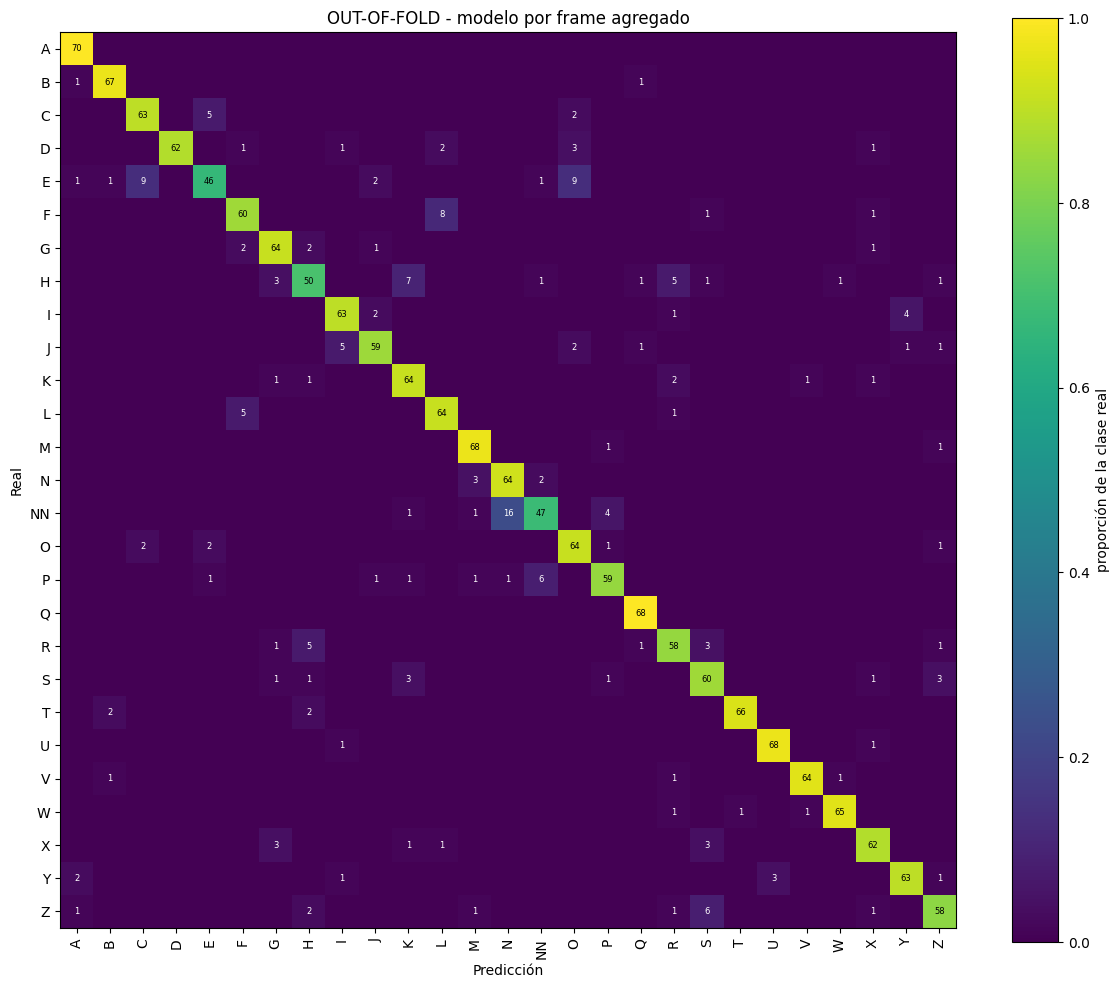

=== TOP 15 CONFUSIONES (real -> predicha) ===
    NN -> N     16
     E -> C     9
     E -> O     9
     F -> L     8
     H -> K     7
     P -> NN    6
     Z -> S     6
     C -> E     5
     H -> R     5
     J -> I     5
     L -> F     5
     R -> H     5
     I -> Y     4
    NN -> P     4
     D -> O     3


In [ ]:
from sklearn.model_selection import GroupKFold

# Validacion cruzada por participante: cada toma se predice exactamente una vez,
# con un modelo que nunca vio a esa persona. Pasa de n=15 a n=70 por clase.
gkf = GroupKFold(n_splits=5)
oof_pred, oof_true = [], []

for k, (i_tr, i_te) in enumerate(gkf.split(X_all, y_all, groups=p_all)):
    m = entrenar(X_all[i_tr], y_all[i_tr], p_all[i_tr], N_CLASES, seed=SEED)
    probs = m.predict(X_all[i_te], verbose=0)
    for _, idxs in indice_tomas(n_all[i_te]).items():
        oof_pred.append(probs[idxs].mean(axis=0).argmax())
        oof_true.append(y_all[i_te][idxs[0]])
    print(f"  fold {k+1}/5 listo ({len(i_te)} frames en test)")

oof_pred, oof_true = np.array(oof_pred), np.array(oof_true)
ACC_OOF_FRAME = (oof_pred == oof_true).mean()
print(f"\nExactitud out-of-fold: {ACC_OOF_FRAME:.4f} "
      f"({len(oof_true)} tomas, cada participante en test exactamente una vez)")


def wilson(k, n, z=1.96):
    """Intervalo de Wilson: el correcto para proporciones con n pequeno.
    El intervalo normal da limites fuera de [0,1] y miente cerca de los extremos."""
    if n == 0:
        return (float("nan"),) * 3
    p = k / n
    d = 1 + z**2/n
    c = (p + z**2/(2*n)) / d
    h = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / d
    return p, max(0.0, c-h), min(1.0, c+h)


def recall_con_ic(y_true, y_pred, etiquetas):
    """[(letra, n, recall, lo, hi)] por clase."""
    filas = []
    for i, c in enumerate(etiquetas):
        m = y_true == i
        p, lo, hi = wilson(int((y_pred[m] == i).sum()), int(m.sum()))
        filas.append((c, int(m.sum()), p, lo, hi))
    return filas


print(f"{'letra':>6} {'n':>4} {'recall':>8}   IC 95%")
filas = recall_con_ic(oof_true, oof_pred, ETIQ_L)
for c, n, p, lo, hi in filas:
    print(f"{c:>6} {n:>4} {p:>8.3f}   [{lo:.3f} - {hi:.3f}]")

print("\nLetras cuyo IC superior queda por DEBAJO de la media global "
      "(problema real, no ruido):")
for c, n, p, lo, hi in filas:
    if hi < ACC_OOF_FRAME:
        print(f"  {c}: {p:.3f}  [{lo:.3f} - {hi:.3f}]")

# Confusiones sobre TODOS los participantes: ahora si son interpretables
reporte(oof_true, oof_pred, ETIQ_L, "OUT-OF-FOLD - modelo por frame agregado")

## 13-bis. El test decisivo: la trayectoria contra N/Ne

Mismo protocolo out-of-fold que el modelo por frame, para que los numeros sean
comparables letra a letra. Se entrenan **tres** variantes sobre exactamente los
mismos folds:

1. **por frame agregado** - la referencia actual (0.897)
2. **temporal sin trayectoria** - lo que se midio antes, con el movimiento amputado
3. **temporal con trayectoria** - la version que si puede ver el desplazamiento

Si la trayectoria sirve, la 3 supera a la 2 y `NN` sube desde 0.768. Si las tres
empatan, el limite no es temporal y la inversion correcta son datos nuevos, no un
modelo nuevo.

In [ ]:
def oof_tomas(XT, yT, pT, etiqueta, arquitectura=ARQ_TEMPORAL):
    """Out-of-fold a nivel de toma, mismos 5 folds por participante."""
    pred, true = [], []
    for k, (i_tr, i_te) in enumerate(GroupKFold(n_splits=5).split(XT, yT, groups=pT)):
        m = entrenar(XT[i_tr], yT[i_tr], pT[i_tr], N_CLASES,
                     seed=SEED, arquitectura=arquitectura)
        pred.extend(m.predict(XT[i_te], verbose=0).argmax(axis=1))
        true.extend(yT[i_te])
        print(f"  [{etiqueta}] fold {k+1}/5 listo ({len(i_te)} tomas)")
    return np.array(pred), np.array(true)


# Conjuntos completos a nivel de toma
XS_all = np.concatenate([XStr, XSte]); yS_all = np.concatenate([ySTr, ySTe])
pS_all = np.concatenate([pSTr, pSTe])

print("Variante 2: temporal SIN trayectoria (control)")
predS, trueS = oof_tomas(XS_all, yS_all, pS_all, "sin tray")
accS = (predS == trueS).mean()

print("\nVariante 3: temporal CON trayectoria")
predT, trueT = oof_tomas(XT_all, yT_all, pT_all, "con tray")
accT = (predT == trueT).mean()

print(f"""
COMPARACION OUT-OF-FOLD (n = {len(oof_true)} tomas)
--------------------------------------------------------
1. por frame agregado        : {ACC_OOF_FRAME:.4f}
2. temporal SIN trayectoria  : {accS:.4f}
3. temporal CON trayectoria  : {accT:.4f}

Aporte de la trayectoria (3 - 2): {accT - accS:+.4f}
Mejor temporal vs por frame     : {max(accS, accT) - ACC_OOF_FRAME:+.4f}
""")

Variante 2: temporal SIN trayectoria (control)
  [sin tray] fold 1/5 listo (373 tomas)
  [sin tray] fold 2/5 listo (373 tomas)
  [sin tray] fold 3/5 listo (373 tomas)
  [sin tray] fold 4/5 listo (373 tomas)
  [sin tray] fold 5/5 listo (372 tomas)

Variante 3: temporal CON trayectoria
  [con tray] fold 1/5 listo (373 tomas)
  [con tray] fold 2/5 listo (373 tomas)
  [con tray] fold 3/5 listo (373 tomas)
  [con tray] fold 4/5 listo (373 tomas)
  [con tray] fold 5/5 listo (372 tomas)

COMPARACION OUT-OF-FOLD (n = 1877 tomas)
--------------------------------------------------------
1. por frame agregado        : 0.8876
2. temporal SIN trayectoria  : 0.8777
3. temporal CON trayectoria  : 0.8841

Aporte de la trayectoria (3 - 2): +0.0064
Mejor temporal vs por frame     : -0.0035



 letra    frame   sin tray   con tray    aporte  significativo
     A    1.000      0.986      0.986    +0.000  -
     B    0.971      0.971      0.957    -0.014  -
     C    0.900      0.871      0.900    +0.029  -
     D    0.886      0.900      0.900    +0.000  -
     E    0.667      0.662      0.691    +0.029  -
     F    0.857      0.900      0.886    -0.014  -
     G    0.914      0.857      0.843    -0.014  -
     H    0.714      0.667      0.697    +0.030  -
     I    0.900      0.886      0.886    +0.000  -
     J    0.855      0.855      0.884    +0.029  -
     K    0.914      0.942      0.942    +0.000  -
     L    0.914      0.886      0.857    -0.029  -
     M    0.971      0.929      0.971    +0.043  -
     N    0.928      0.971      0.928    -0.043  -
    NN    0.681      0.647      0.838    +0.191  -
     O    0.914      0.886      0.886    +0.000  -
     P    0.843      0.886      0.857    -0.029  -
     Q    1.000      1.000      1.000    +0.000  -
     R    0.841    

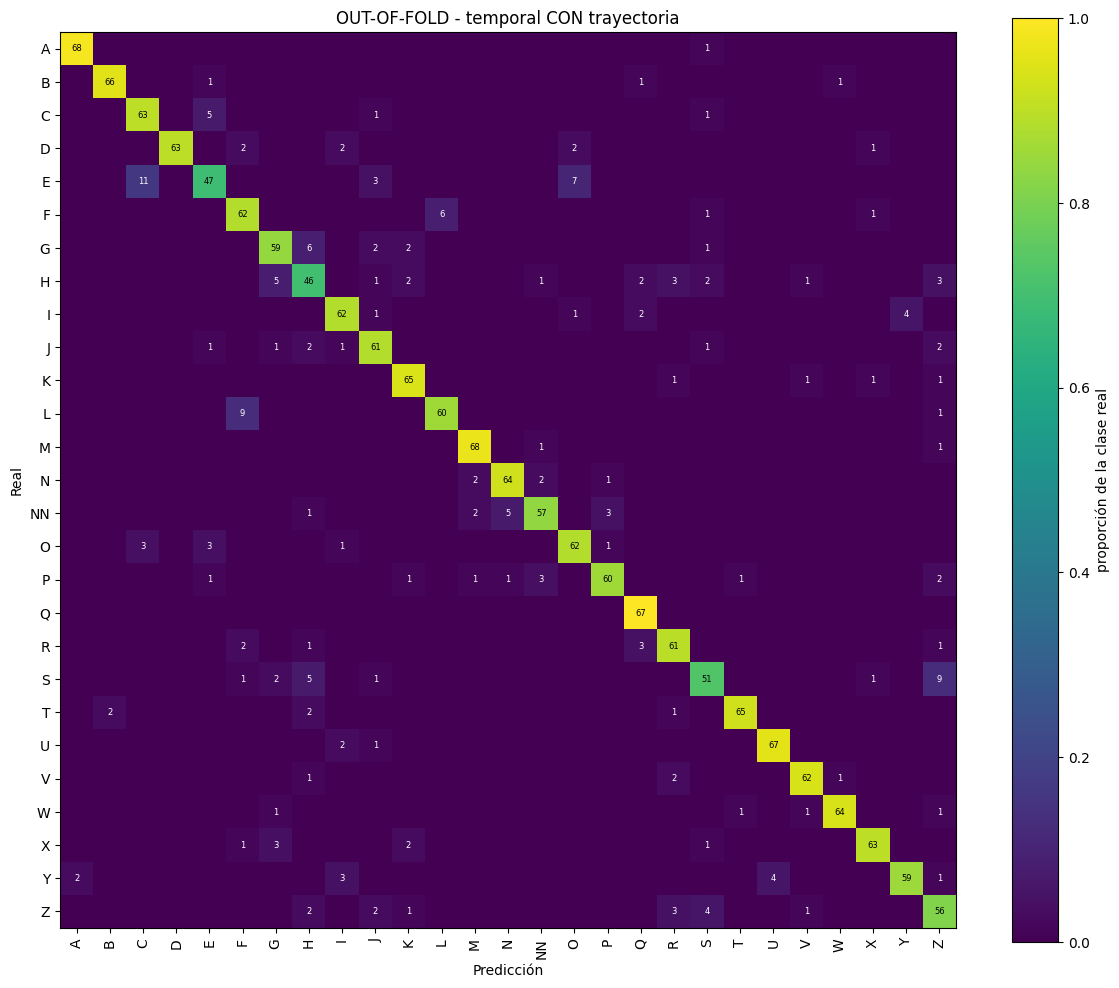

=== TOP 15 CONFUSIONES (real -> predicha) ===
     E -> C     11
     L -> F     9
     S -> Z     9
     E -> O     7
     F -> L     6
     G -> H     6
     C -> E     5
     H -> G     5
    NN -> N     5
     S -> H     5
     I -> Y     4
     Y -> U     4
     Z -> S     4
     E -> J     3
     H -> R     3

VEREDICTO
--------------------------------------------------------
La trayectoria NO aporta de forma apreciable.
El limite no es temporal: es la resolucion de 120x120 para articulacion fina.



In [ ]:
# --- Comparacion por letra, con intervalos de confianza ---
# NOTA: las tres listas OOF vienen en ordenes distintos (folds y agrupaciones
# distintas), asi que solo son comparables AGREGADAS por clase. No las emparejes
# elemento a elemento.
f_frame = {c: (p, lo, hi) for c, n, p, lo, hi in recall_con_ic(oof_true, oof_pred, ETIQ_L)}
f_sin   = {c: (p, lo, hi) for c, n, p, lo, hi in recall_con_ic(trueS, predS, ETIQ_L)}
f_con   = {c: (p, lo, hi) for c, n, p, lo, hi in recall_con_ic(trueT, predT, ETIQ_L)}

print(f"{'letra':>6} {'frame':>8} {'sin tray':>10} {'con tray':>10} {'aporte':>9}  significativo")
for c in ETIQ_L:
    a, b = f_sin[c], f_con[c]
    aporte = b[0] - a[0]
    # Significativo solo si los intervalos de Wilson no se solapan
    sig = "SI" if (b[1] > a[2] or a[1] > b[2]) else "-"
    print(f"{c:>6} {f_frame[c][0]:>8.3f} {a[0]:>10.3f} {b[0]:>10.3f} {aporte:>+9.3f}  {sig}")

print("\n--- FOCO EN EL PAR N / NE ---")
for c in ("NN", "N"):
    if c in f_con:
        i = ETIQ_L.index(c)
        print(f"{c}: frame {f_frame[c][0]:.3f}  sin-tray {f_sin[c][0]:.3f}  "
              f"con-tray {f_con[c][0]:.3f}  IC [{f_con[c][1]:.3f} - {f_con[c][2]:.3f}]")

def cuenta_par(y_true, y_pred, a, b):
    ia, ib = ETIQ_L.index(a), ETIQ_L.index(b)
    return int(((y_true == ia) & (y_pred == ib)).sum())

if "NN" in ETIQ_L and "N" in ETIQ_L:
    print(f"\nConfusiones NN->N :  frame {cuenta_par(oof_true, oof_pred, 'NN', 'N'):>3}"
          f" | sin tray {cuenta_par(trueS, predS, 'NN', 'N'):>3}"
          f" | con tray {cuenta_par(trueT, predT, 'NN', 'N'):>3}")
    print(f"Confusiones N->NN :  frame {cuenta_par(oof_true, oof_pred, 'N', 'NN'):>3}"
          f" | sin tray {cuenta_par(trueS, predS, 'N', 'NN'):>3}"
          f" | con tray {cuenta_par(trueT, predT, 'N', 'NN'):>3}")

reporte(trueT, predT, ETIQ_L, "OUT-OF-FOLD - temporal CON trayectoria")

print(f"""
VEREDICTO
--------------------------------------------------------
{'La trayectoria APORTA: ' + f'{accT-accS:+.4f} global' if accT - accS > 0.01 else
 'La trayectoria NO aporta de forma apreciable.'}
{'Revisa la columna "significativo" para ver en que letras.' if accT - accS > 0.01 else
 'El limite no es temporal: es la resolucion de 120x120 para articulacion fina.'}
""")

In [ ]:
import cv2, numpy as np, os, glob
from collections import defaultdict

# ¿Cuánto cambia la imagen entre el primer y el último frame de cada toma?
base = os.path.join(RUTA_TRABAJO, "train")
tomas = defaultdict(list)
for cls in sorted(os.listdir(base)):
    for r in sorted(glob.glob(os.path.join(base, cls, "*.jpg"))):
        tomas[id_toma(os.path.basename(r))].append(r)

movimiento = defaultdict(list)
for k, rutas in list(tomas.items())[:600]:          # muestra, no hace falta todo
    if len(rutas) < 2:
        continue
    rutas = sorted(rutas, key=lambda r: num_frame(os.path.basename(r)))
    a = cv2.imread(rutas[0], cv2.IMREAD_GRAYSCALE).astype(np.float32)
    b = cv2.imread(rutas[-1], cv2.IMREAD_GRAYSCALE).astype(np.float32)
    movimiento[k.split("__")[1]].append(np.abs(b - a).mean())

print(f"{'letra':>6} {'cambio medio':>14}   (0 = frames idénticos)")
for c, v in sorted(movimiento.items(), key=lambda kv: -np.mean(kv[1])):
    print(f"{c:>6} {np.mean(v):>14.2f}")

todos = [x for v in movimiento.values() for x in v]
print(f"\nGlobal: media {np.mean(todos):.2f} | mínimo {np.min(todos):.2f}")
print("Si la media global está cerca de 0, los 6 frames son la misma pose")
print("y NO hay movimiento que capturar: el experimento no tiene sentido.")

 letra   cambio medio   (0 = frames idénticos)
     J          13.38
     G          11.84
     H           9.81
     A           5.76
     I           5.74
     C           5.46
     K           5.14
     D           4.86
     F           4.66
     E           4.33
     B           3.37

Global: media 6.77 | mínimo 0.81
Si la media global está cerca de 0, los 6 frames son la misma pose
y NO hay movimiento que capturar: el experimento no tiene sentido.


## 14. Exportar

### 14a. Función `exportar` — **rápida, córrela siempre**

Convierte un modelo Keras a `.tflite`. La usa también la Sección 15.

In [ ]:
import shutil

os.makedirs(RUTA_SALIDA, exist_ok=True)

def exportar(modelo, nombre):
    sm = os.path.join(RUTA_SALIDA, f"sm_{nombre}")
    modelo.export(sm)
    conv = tf.lite.TFLiteConverter.from_saved_model(sm)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    ruta = os.path.join(RUTA_SALIDA, f"{nombre}.tflite")
    open(ruta, "wb").write(conv.convert())
    return ruta, os.path.getsize(ruta) / (1024**2)

### 14b. Exportar los modelos del abecedario — **requiere secciones 10-13**

In [ ]:
# Necesita modelo_temp y `resultados`. Sáltala si vas directo a la Sección 15.

ruta_f, tam_f = exportar(modelo_frame, "lsc_abecedario_frame")
ruta_t, tam_t = exportar(modelo_temp,  "lsc_abecedario_temporal")
tam_det = os.path.getsize("/content/hand_landmarker.task") / (1024**2)

np.save(os.path.join(RUTA_SALIDA, "etiquetas.npy"), np.array(ETIQ_L))
for r in (ruta_f, ruta_t):
    shutil.copy(r, "/content/drive/MyDrive/LSC70/")

med_f = np.median(resultados["frame_agg"])
med_t = np.median(resultados["temporal"])
print(f"""
RESUMEN DEL BASELINE
────────────────────────────────────────────────────────
Clases                      : {N_CLASES} (abecedario, sin 'none')
Participantes en test       : {N_PARTICIPANTES_TEST}, disjuntos de train
Descarte por no-detección   : {100*TASA_DESCARTE_TEST:.1f}%

Exactitud por seña, mediana sobre {len(SEMILLAS)} semillas:
  modelo por frame agregado : {med_f:.4f}   [{min(resultados['frame_agg']):.4f} - {max(resultados['frame_agg']):.4f}]
  modelo temporal           : {med_t:.4f}   [{min(resultados['temporal']):.4f} - {max(resultados['temporal']):.4f}]

Efectiva end-to-end (mejor) : {max(med_f, med_t)*(1-TASA_DESCARTE_TEST):.4f}

Tamaños:
  clasificador por frame    : {tam_f:.3f} MB
  clasificador temporal     : {tam_t:.3f} MB
  detector de landmarks     : {tam_det:.2f} MB  (obligatorio en runtime)
  TOTAL a desplegar         : {max(tam_f, tam_t) + tam_det:.2f} MB
""")

# 15. Rechazo de no-señas — SignaCO (RF08)

El clasificador del abecedario siempre devuelve alguna letra: nunca vio nada que no
fuera una letra, así que no tiene forma de dudar. Esta sección le enseña a decir
**"seña no reconocida"**.

## Estrategia elegida: clase explícita + umbral

| opción | por qué sí / por qué no |
|---|---|
| Solo umbral sobre el softmax | **No basta.** La red parte el espacio de 63 dimensiones en 27 regiones que lo cubren entero. Una mano relajada cae dentro de alguna y el softmax sale alto y confiado, porque nunca vio nada fuera del abecedario. |
| Solo clase `no_es_seña` | Aprende bien la frontera (sobre landmarks los negativos ocupan regiones distintas), pero da una decisión dura sin perilla, y RF08 exige un umbral **configurable**. |
| **Ambas** ✅ | La clase moldea la frontera; el umbral da el control del requisito y atrapa lo que la clase no cubre. |

**Regla de rechazo:** `argmax == no_es_seña` **o** `prob(mejor letra) < umbral`.

## Dimensionado de los negativos

La clase de rechazo se fija en **≈ 2× el tamaño medio de una letra**. Más negativos
endurecen la frontera y suben el **falso rechazo**, que en una app de aprendizaje es
el error caro: rechazar una seña bien hecha frustra al usuario y hace ver la app rota.
Aceptar de vez en cuando algo que no era seña solo cuesta un reintento.

El número de muestras es la perilla gruesa. La perilla fina es el umbral, y se elige
contra un **presupuesto de falso rechazo**, no buscando simetría entre los dos errores.

## Riesgo a vigilar

Varios gestos de HaGRID **son letras LSC**: `peace` es la V, `call` es la Y, `palm`
se parece a la B, `ok` a la F. Meterlos como negativos enseñaría al modelo a rechazar
señas válidas. Por eso hay una celda de detección de colisiones antes de elegir nada.

> ## ⛔ NO uses "Ejecutar todas las celdas"
>
> El notebook completo son **2-3 horas**: descompresión, reorganización de ~11.000
> imágenes, dos extracciones de landmarks (~20 min), unos **25 entrenamientos**
> entre las secciones 12, 13 y 13-bis, y el streaming de HaGRID.
>
> En Colab solo corre **una celda a la vez**; las demás quedan **en cola** mostrando
> reloj y sin salida. Eso es lo que parece un cuelgue y casi nunca lo es.
>
> **Orden recomendado:**
>
> 1. Secciones 1-10 una vez → deja el cache en Drive
> 2. Para volver: configuración → instalar mediapipe → **arranque rápido desde cache**
> 3. Secciones 12, 13 y 13-bis **solo si quieres re-medir**; ya tienes esos resultados
> 4. Sección 15 (esta), celda por celda
>
> Para saber si una celda está viva: en Colab la que corre muestra un contador de
> segundos que avanza. Si avanza, espera. Si está parado, interrumpe con
> `Entorno de ejecución → Interrumpir ejecución`.

In [ ]:
# ============================================================
# ARRANQUE RÁPIDO DESDE CACHE
# ============================================================
# Evita re-extraer landmarks (~20 min). Pon el interruptor en True y ejecuta.
#
# ANTES corre solo estas seis celdas, todas rápidas:
#   Configuración        ->  RUTA_ZIP_EN_DRIVE = ...
#   Montar Drive         ->  from google.colab import drive
#   Instalar mediapipe   ->  !pip install --quiet --upgrade mediapipe
#   Sección 6a           ->  detector = vision.HandLandmarker.create_from_options(
#   Sección 8a           ->  def id_toma(nombre):
#   Utilidades           ->  def split_por_grupo(y, grupos, test_size, seed):
#   Sección 13a          ->  def reporte(y_true, y_pred, etiquetas, titulo):
#   Sección 14a          ->  def exportar(modelo, nombre):

USAR_CACHE = True        # <<<<<< PONLO EN True PARA CARGAR DESDE EL CACHE

# La tasa de descarte no se guarda en el cache; es la medida en tu corrida completa.
TASA_DESCARTE_CACHE = 0.028

if USAR_CACHE:
    d = np.load(RUTA_CACHE, allow_pickle=True)
    print("Contenido del cache:", sorted(d.keys()))
    assert "Etr" in d, ("Cache antiguo (sin 'Etr'): se generó con una versión previa. "
                        "Hay que re-extraer una vez con la celda 6b.")

    Xtr, Etr, ytr, ptr, ntr = d["Xtr"], d["Etr"], d["ytr"], d["ptr"], d["ntr"]
    Xte, Ete, yte, pte, nte = d["Xte"], d["Ete"], d["yte"], d["pte"], d["nte"]
    ETIQUETAS = list(d["etiquetas"])

    # Filtrar 'none' (misma lógica que la sección 7)
    i_none = ETIQUETAS.index("none")
    ETIQ_L = [e for e in ETIQUETAS if e != "none"]
    remap = {ETIQUETAS.index(e): i for i, e in enumerate(ETIQ_L)}

    def _filtrar(X, E, y, p, n):
        m = y != i_none
        return X[m], E[m], np.array([remap[v] for v in y[m]]), p[m], n[m]

    Xtr_L, Etr_L, ytr_L, ptr_L, ntr_L = _filtrar(Xtr, Etr, ytr, ptr, ntr)
    Xte_L, Ete_L, yte_L, pte_L, nte_L = _filtrar(Xte, Ete, yte, pte, nte)
    N_CLASES = len(ETIQ_L)

    # Conjuntos combinados y agrupamiento por toma
    X_all = np.concatenate([Xtr_L, Xte_L]); y_all = np.concatenate([ytr_L, yte_L])
    p_all = np.concatenate([ptr_L, pte_L]); n_all = np.concatenate([ntr_L, nte_L])
    frac_test = N_PARTICIPANTES_TEST / len(set(p_all))
    g_tr, g_te = indice_tomas(ntr_L), indice_tomas(nte_L)
    TASA_DESCARTE_TEST = TASA_DESCARTE_CACHE

    # Comprobación de integridad: nombre de archivo vs etiqueta
    malos = sum(1 for nm, yy in zip(ntr_L, ytr_L) if nm.split("__")[1] != ETIQ_L[yy])
    assert malos == 0, f"{malos} nombres desalineados con sus etiquetas"

    # Modelo de letras (~1 min); lo necesita la detección de colisiones
    modelo_frame = entrenar(Xtr_L, ytr_L, ptr_L, N_CLASES, seed=SEED, verbose=0)

    print(f"\nListo. Letras: {N_CLASES} | frames: {len(y_all)} | "
          f"participantes: {len(set(p_all))} | integridad OK")
else:
    print("USAR_CACHE = False. Si ya corriste la extracción completa en esta sesión,")
    print("no hace falta tocar nada. Si reiniciaste el runtime, ponlo en True.")

Contenido del cache: ['Ete', 'Etr', 'Xte', 'Xtr', 'etiquetas', 'nte', 'ntr', 'pte', 'ptr', 'yte', 'ytr']

Listo. Letras: 27 | frames: 10809 | participantes: 70 | integridad OK


In [ ]:
!pip install --quiet datasets

In [ ]:
from datasets import load_dataset_builder, load_dataset
from collections import Counter

REPO_HAGRID = "cj-mills/hagrid-classification-512p-no-gesture-150k"

# load_dataset_builder lee los METADATOS sin descargar ni una imagen.
builder = load_dataset_builder(REPO_HAGRID)

print("=== FEATURES (esquema del dataset) ===")
for k, v in builder.info.features.items():
    print(f"  {k}: {v}")

print("\n=== SPLITS ===")
for nombre, info in (builder.info.splits or {}).items():
    print(f"  {nombre}: {info.num_examples:,} ejemplos")

# Localizar columnas sin asumir nombres: el esquema de los subsets reempaquetados varía.
COL_LABEL = next((k for k, v in builder.info.features.items()
                  if hasattr(v, "names")), None)
COL_IMG   = next((k for k, v in builder.info.features.items()
                  if type(v).__name__ == "Image"), None)
COL_USER  = next((k for k in builder.info.features
                  if "user" in k.lower() or "subject" in k.lower()), None)
CLASES_HAGRID = list(builder.info.features[COL_LABEL].names) if COL_LABEL else []

print(f"\nColumna de etiqueta   : {COL_LABEL}")
print(f"Columna de imagen     : {COL_IMG}")
print(f"Columna de participante: {COL_USER if COL_USER else 'NO EXISTE'}")
if not COL_USER:
    print("  -> Sin user_id no se puede garantizar disjuncion por persona entre")
    print("     los negativos. Afecta solo a la tasa de FALSA ACEPTACION (quedaria")
    print("     algo optimista), no al falso rechazo, que se mide sobre tus letras")
    print("     con el split por participante intacto. Documentalo como limitacion.")

print(f"\n=== {len(CLASES_HAGRID)} CLASES ===")
for i, c in enumerate(CLASES_HAGRID):
    print(f"  {i:>2}  {c}")

assert COL_LABEL and COL_IMG, "No se pudo identificar el esquema; revisa las FEATURES"

README.md:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

=== FEATURES (esquema del dataset) ===
  image: Image(mode=None, decode=True)
  label: ClassLabel(names=['call', 'dislike', 'fist', 'four', 'like', 'mute', 'no_gesture', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted', 'three', 'three2', 'two_up', 'two_up_inverted'])

=== SPLITS ===
  train: 153,735 ejemplos

Columna de etiqueta   : label
Columna de imagen     : image
Columna de participante: NO EXISTE
  -> Sin user_id no se puede garantizar disjuncion por persona entre
     los negativos. Afecta solo a la tasa de FALSA ACEPTACION (quedaria
     algo optimista), no al falso rechazo, que se mide sobre tus letras
     con el split por participante intacto. Documentalo como limitacion.

=== 19 CLASES ===
   0  call
   1  dislike
   2  fist
   3  four
   4  like
   5  mute
   6  no_gesture
   7  ok
   8  one
   9  palm
  10  peace
  11  peace_inverted
  12  rock
  13  stop
  14  stop_inverted
  15  three
  16  three2
  17  two_up
  18  two_up_inverted


In [ ]:
# Distribución por clase, estimada en streaming (sin tocar disco).
N_MUESTRA = 4000
conteo_hagrid = Counter()
for i, ej in enumerate(load_dataset(REPO_HAGRID, split="train", streaming=True)):
    if i >= N_MUESTRA:
        break
    conteo_hagrid[CLASES_HAGRID[ej[COL_LABEL]]] += 1

total_real = builder.info.splits["train"].num_examples
print(f"Distribución estimada sobre {N_MUESTRA:,} de {total_real:,} imágenes:\n")
print(f"{'clase':>18} {'muestra':>9} {'%':>7} {'estimado total':>16}")
for c, n in conteo_hagrid.most_common():
    print(f"{c:>18} {n:>9} {100*n/N_MUESTRA:>6.1f}% {int(total_real*n/N_MUESTRA):>16,}")

Distribución estimada sobre 4,000 de 153,735 imágenes:

             clase   muestra       %   estimado total
              call      4000  100.0%          153,735


⚠️ **VERIFICACIÓN 1.** Confirma que aparece `no_gesture` entre las clases y que las
demás son las 18 de HaGRID. Fíjate sobre todo en si existe columna de participante:
si no existe, el mensaje de arriba explica el alcance real de esa limitación.

In [ ]:
import numpy as np
import mediapipe as mp
import time

# ¿Qué gestos de HaGRID confunde tu modelo actual con letras del abecedario?
# Los que confunda con ALTA confianza son letras disfrazadas: NO pueden ser negativos.
N_SONDEO      = 40      # imágenes por clase (bajado de 60: sobra para decidir)
UMBRAL_SONDEO = 0.75    # el default de tu RF08
MAX_STREAM_SONDEO = 1200000   # TOPE DURO de imágenes a leer del stream


def landmarks_de_pil(img_pil):
    """Extrae features usando EXACTAMENTE la vector_features del abecedario.

    No se reimplementa la normalización a propósito: reusar la función es la única
    garantía de que los negativos viven en el mismo espacio que los positivos.
    """
    arr = np.ascontiguousarray(np.array(img_pil.convert("RGB"), dtype=np.uint8))
    img_mp = mp.Image(image_format=mp.ImageFormat.SRGB, data=arr)
    res = detector.detect(img_mp)
    if not res.hand_landmarks:
        return None
    es_izq = bool(res.handedness) and res.handedness[0][0].category_name == "Left"
    v, _ = vector_features(res.hand_landmarks[0], es_izq)
    return v


assert Xtr_L.shape[1] == 63, f"Dimensión inesperada: {Xtr_L.shape[1]}"
print(f"Espacio de features OK: {Xtr_L.shape[1]} dims | modelo de letras: {N_CLASES} clases")
print(f"Sondeo: hasta {N_SONDEO} imgs/clase, leyendo como mucho {MAX_STREAM_SONDEO:,} del stream.\n")

sondeo = {c: [] for c in CLASES_HAGRID}
leidas = 0
t0 = time.time()

# El tope duro evita el cuelgue: si una clase nunca llega a N_SONDEO (porque
# MediaPipe casi no detecta mano en ella), el bucle terminaría recorriendo las
# 150.000 imágenes. Se corta y se reporta qué clases quedaron cortas.
for ej in load_dataset(REPO_HAGRID, split="train", streaming=True):
    leidas += 1
    if leidas > MAX_STREAM_SONDEO:
        print(f"Tope de {MAX_STREAM_SONDEO:,} imágenes alcanzado; se corta el sondeo.")
        break
    if leidas % 1000 == 0:
        llenas = sum(1 for v in sondeo.values() if len(v) >= N_SONDEO)
        print(f"  {leidas:>6,} leídas | {llenas}/{len(CLASES_HAGRID)} clases completas "
              f"| {time.time()-t0:.0f}s")
    c = CLASES_HAGRID[ej[COL_LABEL]]
    if len(sondeo[c]) >= N_SONDEO:
        if all(len(v) >= N_SONDEO for v in sondeo.values()):
            break
        continue
    v = landmarks_de_pil(ej[COL_IMG])
    if v is not None:
        sondeo[c].append(v)

print(f"\nSondeo terminado en {time.time()-t0:.0f}s ({leidas:,} imágenes leídas).\n")

print(f"{'clase HaGRID':>18} {'n':>4} {'% como letra':>14} {'letra dominante':>16} {'conf':>7}")
colisiones, sin_datos = [], []
for c in CLASES_HAGRID:
    if len(sondeo[c]) < 10:            # muestra insuficiente para concluir nada
        sin_datos.append(c)
        print(f"{c:>18} {len(sondeo[c]):>4}   muestra insuficiente")
        continue
    P = modelo_frame.predict(np.array(sondeo[c]), verbose=0)
    conf, pred = P.max(axis=1), P.argmax(axis=1)
    tasa = float((conf >= UMBRAL_SONDEO).mean())
    dom = ETIQ_L[Counter(pred[conf >= UMBRAL_SONDEO]).most_common(1)[0][0]] if tasa > 0 else "-"
    marca = "  <-- COLISIONA" if tasa >= 0.50 else ""
    colisiones.append((c, tasa, dom))
    print(f"{c:>18} {len(sondeo[c]):>4} {100*tasa:>13.1f}% {dom:>16} {conf.mean():>7.3f}{marca}")

print("\nCOLISIONAN (>=50% clasificadas como letra con conf>=0.75) - NO usar:")
print("  ", [c for c, t, _ in colisiones if t >= 0.50] or "ninguna")
print("\nCANDIDATAS A NEGATIVO DIFÍCIL:")
print("  ", [c for c, t, _ in colisiones if t < 0.50 and c != "no_gesture"])
if sin_datos:
    print("\nSin muestra suficiente (MediaPipe casi no detecta mano):", sin_datos)
    print("  Tampoco sirven como negativos: no podrías extraerles landmarks.")

Espacio de features OK: 63 dims | modelo de letras: 27 clases
Sondeo: hasta 40 imgs/clase, leyendo como mucho 1,200,000 del stream.

   1,000 leídas | 1/19 clases completas | 11s
   2,000 leídas | 1/19 clases completas | 15s
   3,000 leídas | 1/19 clases completas | 18s
   4,000 leídas | 1/19 clases completas | 20s
   5,000 leídas | 1/19 clases completas | 21s
   6,000 leídas | 1/19 clases completas | 23s
   7,000 leídas | 2/19 clases completas | 26s
   8,000 leídas | 2/19 clases completas | 28s
   9,000 leídas | 2/19 clases completas | 30s
  10,000 leídas | 2/19 clases completas | 33s
  11,000 leídas | 2/19 clases completas | 34s
  12,000 leídas | 2/19 clases completas | 36s
  13,000 leídas | 2/19 clases completas | 38s
  14,000 leídas | 2/19 clases completas | 41s
  15,000 leídas | 3/19 clases completas | 43s
  16,000 leídas | 3/19 clases completas | 45s
  17,000 leídas | 3/19 clases completas | 47s
  18,000 leídas | 3/19 clases completas | 49s
  19,000 leídas | 3/19 clases completas

⚠️ **VERIFICACIÓN 2 — la más importante.** Mira la columna `letra dominante`. Si
`peace` sale como V, `call` como Y o `palm` como B, esas clases **son letras LSC** y no
pueden ser negativos. Copia la lista de candidatas a la celda siguiente, quitando a
mano cualquiera que reconozcas como seña real del abecedario aunque el sondeo no la
haya marcado — el sondeo usa tu propio modelo, que también se equivoca.

In [ ]:
# ============================================================
# CONFIGURACIÓN DE NEGATIVOS — edítala tras ver la celda anterior
# ============================================================
CLASES_NEG_FACILES   = ["no_gesture"]
CLASES_NEG_DIFICILES = []      # <-- PÉGALAS AQUÍ desde la detección de colisiones

RATIO_NEGATIVOS  = 2.0    # tamaño de 'no_es_seña' respecto a una letra media
PROP_DIFICILES   = 0.5    # mitad fáciles, mitad difíciles
ETIQUETA_RECHAZO = "no_es_seña"

# El objetivo se dimensiona sobre TUS datos, no sobre un número inventado
frames_por_letra = len(y_all) / len(ETIQ_L)
N_NEG_OBJETIVO   = int(RATIO_NEGATIVOS * frames_por_letra)
n_dificiles = int(N_NEG_OBJETIVO * PROP_DIFICILES) if CLASES_NEG_DIFICILES else 0
n_faciles   = N_NEG_OBJETIVO - n_dificiles

print(f"Frames por letra (media): {frames_por_letra:.0f}")
print(f"Negativos objetivo: {N_NEG_OBJETIVO}  ({n_faciles} fáciles + {n_dificiles} difíciles)")
if not CLASES_NEG_DIFICILES:
    print("\n⚠️  Sin negativos difíciles el modelo aprenderá a rechazar manos relajadas,")
    print("    pero no gestos deliberados que no son letras. Añade alguna clase.")

Frames por letra (media): 400
Negativos objetivo: 800  (800 fáciles + 0 difíciles)

⚠️  Sin negativos difíciles el modelo aprenderá a rechazar manos relajadas,
    pero no gestos deliberados que no son letras. Añade alguna clase.


In [ ]:
from tqdm import tqdm
import time

MAX_STREAM_NEG = 1200000     # TOPE DURO de imágenes a leer del stream


def cupo_por_clase(clases, total):
    return {c: total // len(clases) for c in clases} if clases else {}


cupos = {**cupo_por_clase(CLASES_NEG_FACILES, n_faciles),
         **cupo_por_clase(CLASES_NEG_DIFICILES, n_dificiles)}
print("Cupos por clase:", cupos)
assert cupos, "No hay clases negativas seleccionadas"

X_neg, meta_neg = [], []
recogidas, procesadas = Counter(), Counter()
leidas = 0
t0 = time.time()
barra = tqdm(total=sum(cupos.values()), desc="Negativos")

# Tope duro: si la tasa de deteccion de MediaPipe es baja, llenar los cupos podria
# requerir recorrer el dataset entero. Se corta y se trabaja con lo recogido.
for ej in load_dataset(REPO_HAGRID, split="train", streaming=True):
    leidas += 1
    if leidas > MAX_STREAM_NEG:
        print(f"\nTope de {MAX_STREAM_NEG:,} imágenes alcanzado; se corta la recolección.")
        break
    c = CLASES_HAGRID[ej[COL_LABEL]]
    if c not in cupos or recogidas[c] >= cupos[c]:
        if all(recogidas[k] >= v for k, v in cupos.items()):
            break
        continue
    procesadas[c] += 1
    v = landmarks_de_pil(ej[COL_IMG])
    if v is None:
        continue                      # MediaPipe no vio mano
    X_neg.append(v)
    meta_neg.append((c, ej.get(COL_USER) if COL_USER else None))
    recogidas[c] += 1
    barra.update(1)
barra.close()

X_neg = np.array(X_neg, dtype=np.float32)
print(f"\nRecolección: {time.time()-t0:.0f}s | {leidas:,} imágenes leídas del stream")

# ===== DESCARTE POR NO-DETECCIÓN =====
print(f"\n{'clase':>18} {'cupo':>6} {'procesadas':>11} {'retenidas':>10} {'descarte %':>11}")
tp = tr = 0
for c in cupos:
    p, r = procesadas[c], recogidas[c]
    tp += p; tr += r
    corto = "  <-- CUPO SIN LLENAR" if r < cupos[c] else ""
    print(f"{c:>18} {cupos[c]:>6} {p:>11} {r:>10} {100*(p-r)/max(p,1):>10.1f}%{corto}")
print(f"{'TOTAL':>18} {sum(cupos.values()):>6} {tp:>11} {tr:>10} {100*(tp-tr)/max(tp,1):>10.1f}%")
print(f"\nNegativos finales: {X_neg.shape}")
print(f"Referencia: el descarte en el abecedario fue {100*TASA_DESCARTE_TEST:.1f}%")
assert len(X_neg) >= 200, "Muy pocos negativos; sube MAX_STREAM_NEG o revisa las clases"

Cupos por clase: {'no_gesture': 800}


Negativos: 100%|██████████| 800/800 [02:28<00:00,  5.38it/s]


Recolección: 149s | 42,929 imágenes leídas del stream

             clase   cupo  procesadas  retenidas  descarte %
        no_gesture    800         934        800       14.3%
             TOTAL    800         934        800       14.3%

Negativos finales: (800, 63)
Referencia: el descarte en el abecedario fue 2.8%


⚠️ **VERIFICACIÓN 3.** El descarte aquí será bastante mayor que tu 2.8 %: HaGRID son
escenas completas de 512 px donde la mano ocupa una fracción pequeña, no recortes
centrados. Un 20-40 % es normal y solo significa procesar más imágenes para llenar el
cupo. Señal de alarma real: por encima del 70 %.

In [ ]:
if COL_USER and any(m[1] for m in meta_neg):
    grupos_neg = np.array([f"hagrid_{m[1]}" for m in meta_neg])
    print("✓ Split de negativos por user_id real de HaGRID")
else:
    # Si no hay user_id, se asigna un grupo único a cada negativo para asegurar su split.
    # Esto garantiza que haya negativos en test, pero no hay disjunción por persona.
    grupos_neg = np.array([f"hagrid_neg_idx_{i}" for i in range(len(meta_neg))])
    print("⚠️  HaGRID sin user_id: los negativos se agrupan individualmente para el split.")
    print("    Esto garantiza que haya negativos en test, pero no hay disjunción por persona.")
    print("    Afecta solo a la falsa aceptación, no al falso rechazo.")

# --- Dataset combinado ---
IDX_RECHAZO = len(ETIQ_L)
ETIQ_R = list(ETIQ_L) + [ETIQUETA_RECHAZO]

X_R = np.concatenate([X_all, X_neg])
y_R = np.concatenate([y_all, np.full(len(X_neg), IDX_RECHAZO)])
g_R = np.concatenate([p_all, grupos_neg])
es_letra = np.concatenate([np.ones(len(y_all), bool), np.zeros(len(X_neg), bool)])

print(f"\nTotal: {X_R.shape} | clases: {len(ETIQ_R)}")
print(f"  letras   : {es_letra.sum():>6}")
print(f"  negativos: {(~es_letra).sum():>6} ({100*(~es_letra).mean():.1f}% del total)")
print(f"  ratio negativos / letra media: {(~es_letra).sum()/frames_por_letra:.2f}x")

# --- Split sin solapamiento de grupos ---
i_tr, i_te = split_por_grupo(y_R, g_R, test_size=frac_test, seed=SEED)
assert not (set(g_R[i_tr]) & set(g_R[i_te])), "FUGA DE PARTICIPANTE"
print(f"\nTrain {len(i_tr)} | Test {len(i_te)} | solapamiento de grupos: 0 ✓")
print(f"Negativos en test: {(~es_letra[i_te]).sum()}")
assert (~es_letra[i_te]).sum() >= 50, "Muy pocos negativos en test para medir la FAR"

⚠️  HaGRID sin user_id: los negativos se agrupan individualmente para el split.
    Esto garantiza que haya negativos en test, pero no hay disjunción por persona.
    Afecta solo a la falsa aceptación, no al falso rechazo.

Total: (11609, 63) | clases: 28
  letras   :  10809
  negativos:    800 (6.9% del total)
  ratio negativos / letra media: 2.00x

Train 8992 | Test 2617 | solapamiento de grupos: 0 ✓
Negativos en test: 171


In [ ]:
# Sin class_weight a propósito: la clase de rechazo ya está dimensionada a 2x una
# letra. Balancearla contra el TOTAL de positivos la haría dominar y dispararía el
# falso rechazo, que es el error caro en una app de aprendizaje.
modelo_rechazo = entrenar(X_R[i_tr], y_R[i_tr], g_R[i_tr],
                          len(ETIQ_R), seed=SEED, verbose=2)

probs_rej = modelo_rechazo.predict(X_R[i_te], verbose=0)
y_te_R, letra_te = y_R[i_te], es_letra[i_te]
print(f"\nExactitud bruta sobre {len(ETIQ_R)} clases: "
      f"{(probs_rej.argmax(axis=1) == y_te_R).mean():.4f}")
print("(No es la métrica que importa: mira las tasas de rechazo abajo.)")

Epoch 1/200
478/478 - 8s - 17ms/step - accuracy: 0.4709 - loss: 1.7811 - val_accuracy: 0.7537 - val_loss: 0.9038
Epoch 2/200
478/478 - 2s - 4ms/step - accuracy: 0.6704 - loss: 1.0741 - val_accuracy: 0.8033 - val_loss: 0.6534
Epoch 3/200
478/478 - 2s - 3ms/step - accuracy: 0.7219 - loss: 0.9084 - val_accuracy: 0.8247 - val_loss: 0.5633
Epoch 4/200
478/478 - 2s - 3ms/step - accuracy: 0.7474 - loss: 0.8308 - val_accuracy: 0.8432 - val_loss: 0.5409
Epoch 5/200
478/478 - 2s - 3ms/step - accuracy: 0.7571 - loss: 0.7809 - val_accuracy: 0.8521 - val_loss: 0.5128
Epoch 6/200
478/478 - 2s - 3ms/step - accuracy: 0.7695 - loss: 0.7414 - val_accuracy: 0.8454 - val_loss: 0.5175
Epoch 7/200
478/478 - 2s - 3ms/step - accuracy: 0.7792 - loss: 0.7048 - val_accuracy: 0.8469 - val_loss: 0.4800
Epoch 8/200
478/478 - 2s - 4ms/step - accuracy: 0.7827 - loss: 0.7008 - val_accuracy: 0.8469 - val_loss: 0.5031
Epoch 9/200
478/478 - 3s - 6ms/step - accuracy: 0.7901 - loss: 0.6779 - val_accuracy: 0.8521 - val_loss

In [ ]:
def decidir(probs, umbral):
    """Regla de RF08: rechaza si gana 'no_es_seña' O si la mejor letra no llega al umbral."""
    p_letras = probs[:, :IDX_RECHAZO]
    pred = p_letras.argmax(axis=1)
    conf = p_letras.max(axis=1)
    rechazado = (probs.argmax(axis=1) == IDX_RECHAZO) | (conf < umbral)
    return pred, conf, rechazado


def metricas(umbral):
    """(falso rechazo, falsa aceptación, acierto sobre lo aceptado)."""
    pred, _, rech = decidir(probs_rej, umbral)
    frr = rech[letra_te].mean()             # rechaza una letra válida  <- error CARO
    far = (~rech[~letra_te]).mean()         # acepta algo que no es letra <- tolerable
    acep = letra_te & ~rech
    acc = (pred[acep] == y_te_R[acep]).mean() if acep.sum() else float("nan")
    return frr, far, acc


umbrales = np.arange(0.0, 1.0, 0.01)
M = np.array([metricas(u) for u in umbrales])
FRR, FAR, ACC = M[:, 0], M[:, 1], M[:, 2]

# --- Elección con TU criterio de costos, no simetría entre errores ---
FRR_PRESUPUESTO = 0.03        # máximo 3% de señas correctas rechazadas
viables = np.where(FRR <= FRR_PRESUPUESTO)[0]
u_opt = float(umbrales[viables[-1]]) if len(viables) else 0.0   # el más alto que cabe

print(f"{'umbral':>8} {'falso rechazo':>15} {'falsa aceptación':>18} {'acc aceptadas':>15}")
for u in [0.0, 0.3, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9]:
    f, a, c = metricas(u)
    marca = "  <-- default RF08" if abs(u - 0.75) < 1e-9 else ""
    print(f"{u:>8.2f} {100*f:>14.1f}% {100*a:>17.1f}% {100*c:>14.1f}%{marca}")

f_opt, a_opt, c_opt = metricas(u_opt)
f75, a75, c75 = metricas(0.75)
print(f"\n>>> UMBRAL RECOMENDADO: {u_opt:.2f}")
print(f"    falso rechazo            : {100*f_opt:.1f}%  (presupuesto {100*FRR_PRESUPUESTO:.0f}%)")
print(f"    falsa aceptación         : {100*a_opt:.1f}%")
print(f"    acierto sobre lo aceptado: {100*c_opt:.1f}%")
print(f"\n    Con el 0.75 de tu RF08   : FRR {100*f75:.1f}% | FAR {100*a75:.1f}%")
print("    Ojo: al añadir la clase de rechazo, la probabilidad de la mejor letra baja")
print("    de forma natural, así que 0.75 es MÁS estricto que antes. Si el FRR a 0.75")
print("    se dispara, actualiza el valor por defecto de RF08 al recomendado.")

  umbral   falso rechazo   falsa aceptación   acc aceptadas
    0.00            0.9%               4.7%           85.8%
    0.30            1.3%               4.1%           86.0%
    0.50            6.2%               2.3%           88.4%
    0.60           13.0%               2.3%           91.0%
    0.70           19.3%               1.8%           92.9%
    0.75           22.9%               1.8%           94.3%  <-- default RF08
    0.80           26.8%               1.2%           95.4%
    0.90           36.5%               0.0%           97.1%

>>> UMBRAL RECOMENDADO: 0.40
    falso rechazo            : 2.9%  (presupuesto 3%)
    falsa aceptación         : 4.1%
    acierto sobre lo aceptado: 86.8%

    Con el 0.75 de tu RF08   : FRR 22.9% | FAR 1.8%
    Ojo: al añadir la clase de rechazo, la probabilidad de la mejor letra baja
    de forma natural, así que 0.75 es MÁS estricto que antes. Si el FRR a 0.75
    se dispara, actualiza el valor por defecto de RF08 al recomendado.


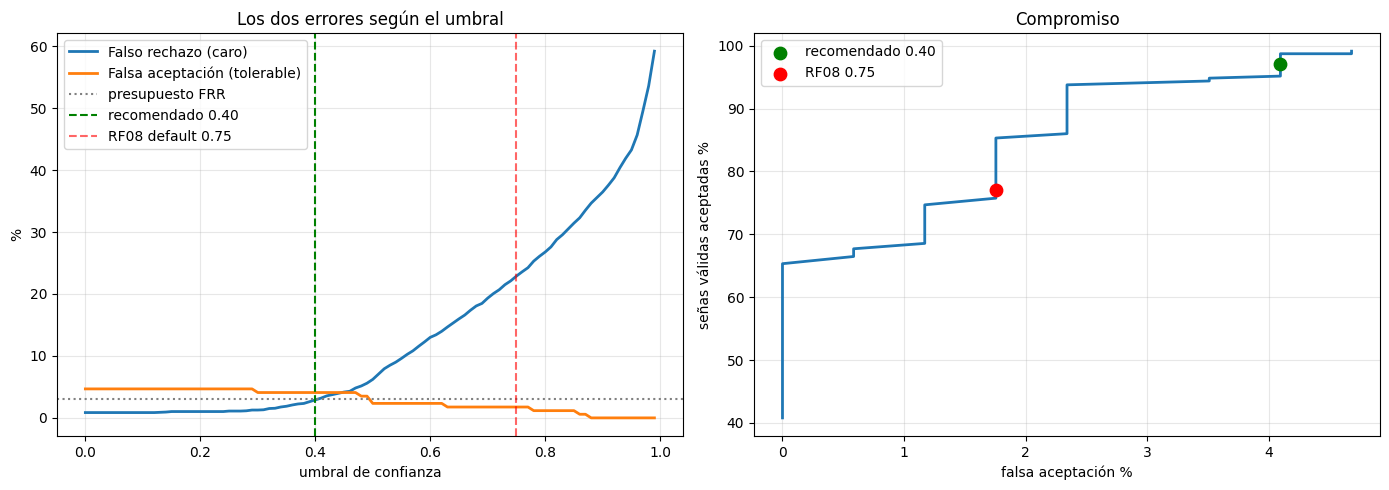

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(umbrales, 100*FRR, lw=2, label="Falso rechazo (caro)")
ax[0].plot(umbrales, 100*FAR, lw=2, label="Falsa aceptación (tolerable)")
ax[0].axhline(100*FRR_PRESUPUESTO, ls=":", c="gray", label="presupuesto FRR")
ax[0].axvline(u_opt, ls="--", c="green", label=f"recomendado {u_opt:.2f}")
ax[0].axvline(0.75, ls="--", c="red", alpha=.6, label="RF08 default 0.75")
ax[0].set_xlabel("umbral de confianza"); ax[0].set_ylabel("%")
ax[0].set_title("Los dos errores según el umbral")
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(100*FAR, 100*(1-FRR), lw=2)
i_o  = int(np.argmin(np.abs(umbrales - u_opt)))
i_75 = int(np.argmin(np.abs(umbrales - 0.75)))
ax[1].scatter([100*FAR[i_o]], [100*(1-FRR[i_o])], c="green", s=80, zorder=5,
              label=f"recomendado {u_opt:.2f}")
ax[1].scatter([100*FAR[i_75]], [100*(1-FRR[i_75])], c="red", s=80, zorder=5,
              label="RF08 0.75")
ax[1].set_xlabel("falsa aceptación %"); ax[1].set_ylabel("señas válidas aceptadas %")
ax[1].set_title("Compromiso"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

Al umbral 0.40:

 letra     n   rechazadas      FRR
     A    95            0     0.0%
     B    90            4     4.4%
     C    95            1     1.1%
     D    96            0     0.0%
     E    95            4     4.2%
     F    96            0     0.0%
     G    91            1     1.1%
     H    63            6     9.5%  <-- REVISAR
     I    95            0     0.0%
     J    81            7     8.6%
     K    91            0     0.0%
     L    93            0     0.0%
     M    94            4     4.3%
     N    89            8     9.0%
    NN    85            6     7.1%
     O    96            0     0.0%
     P    96            1     1.0%
     Q    83            0     0.0%
     R    93            6     6.5%
     S    88            8     9.1%  <-- REVISAR
     T    96            1     1.0%
     U    96            1     1.0%
     V    90            3     3.3%
     W    94            0     0.0%
     X    95            2     2.1%
     Y    94            0     0.0%
     Z    76

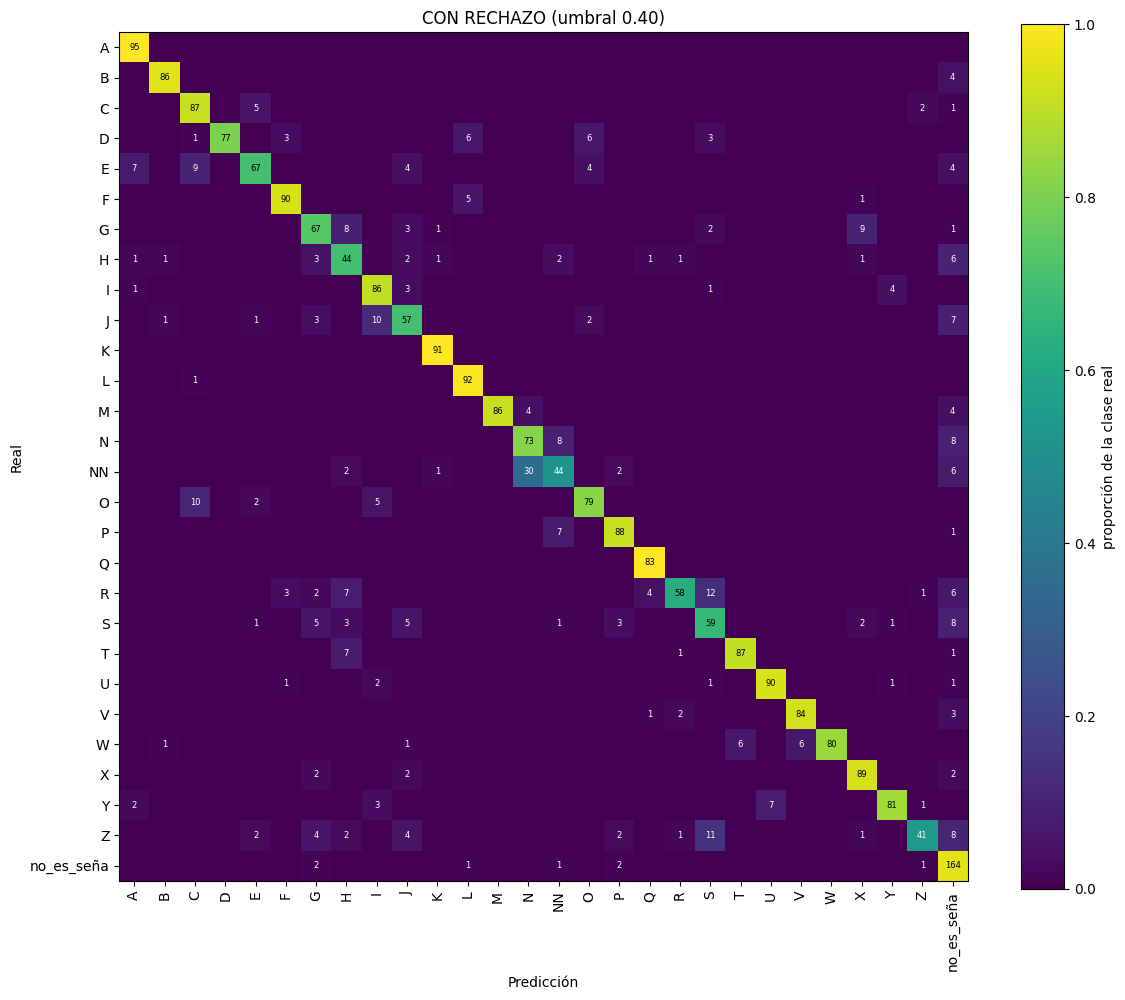

=== TOP 15 CONFUSIONES (real -> predicha) ===
    NN -> N     30
     R -> S     12
     Z -> S     11
     J -> I     10
     O -> C     10
     E -> C     9
     G -> X     9
     G -> H     8
     N -> NN    8
     N -> no_es_seña  8
     S -> no_es_seña  8
     Z -> no_es_seña  8
     E -> A     7
     J -> no_es_seña  7
     P -> NN    7


In [ ]:
# --- Falso rechazo POR LETRA: ¿hay alguna que la app rechace sistemáticamente? ---
pred_o, conf_o, rech_o = decidir(probs_rej, u_opt)
print(f"Al umbral {u_opt:.2f}:\n")
print(f"{'letra':>6} {'n':>5} {'rechazadas':>12} {'FRR':>8}")
problematicas = []
for i, c in enumerate(ETIQ_L):
    m = letra_te & (y_te_R == i)
    if m.sum() == 0:
        continue
    frr_c = rech_o[m].mean()
    if frr_c > 3 * FRR_PRESUPUESTO:
        problematicas.append(c)
    aviso = "  <-- REVISAR" if frr_c > 3 * FRR_PRESUPUESTO else ""
    print(f"{c:>6} {m.sum():>5} {int(rech_o[m].sum()):>12} {100*frr_c:>7.1f}%{aviso}")

print(f"\nLetras con falso rechazo elevado: {problematicas or 'ninguna'}")

# --- Matriz de confusión con el rechazo como clase extra ---
p_vis = np.where(rech_o, IDX_RECHAZO, pred_o)
reporte(y_te_R, p_vis, ETIQ_R, f"CON RECHAZO (umbral {u_opt:.2f})")

⚠️ **VERIFICACIÓN 4.** Mira la tabla de falso rechazo por letra. E, H, Ñ y P son tus
letras flojas y van a concentrar los rechazos. Si alguna supera el 10 %, en la app esa
letra se va a sentir rota: baja `FRR_PRESUPUESTO` a 0.02 y vuelve a correr **solo** la
celda de métricas — no hace falta reentrenar, el umbral es un parámetro de inferencia.

In [ ]:
import json, shutil

ruta_r, tam_r = exportar(modelo_rechazo, "signaco_abecedario_rechazo")
tam_det  = os.path.getsize("/content/hand_landmarker.task") / (1024**2)
total_mb = tam_r + tam_det

np.save(os.path.join(RUTA_SALIDA, "etiquetas_rechazo.npy"), np.array(ETIQ_R))
config = {
    "umbral_por_defecto": round(u_opt, 2),
    "indice_rechazo": IDX_RECHAZO,
    "etiquetas": ETIQ_R,
    "frr_medido": round(float(f_opt), 4),
    "far_medido": round(float(a_opt), 4),
    "acc_sobre_aceptadas": round(float(c_opt), 4),
    "negativos_faciles": CLASES_NEG_FACILES,
    "negativos_dificiles": CLASES_NEG_DIFICILES,
    "n_negativos": int(len(X_neg)),
}
with open(os.path.join(RUTA_SALIDA, "config_rechazo.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

shutil.copy(ruta_r, "/content/drive/MyDrive/LSC70/")
shutil.copy(os.path.join(RUTA_SALIDA, "config_rechazo.json"), "/content/drive/MyDrive/LSC70/")

print(f"""
SIGNACO - MODELO CON RECHAZO
────────────────────────────────────────────────
Clases                   : {len(ETIQ_R)} (27 letras + {ETIQUETA_RECHAZO})
Negativos usados         : {len(X_neg)} ({', '.join(CLASES_NEG_FACILES + CLASES_NEG_DIFICILES)})
Umbral recomendado       : {u_opt:.2f}
Falso rechazo            : {100*f_opt:.1f}%
Falsa aceptación         : {100*a_opt:.1f}%
Acierto sobre aceptadas  : {100*c_opt:.1f}%

TAMAÑOS
  clasificador           : {tam_r:.3f} MB
  detector de landmarks  : {tam_det:.2f} MB
  TOTAL A DESPLEGAR      : {total_mb:.2f} MB
  RNF-03 (máximo 20 MB)  : {'CUMPLE' if total_mb <= 20 else 'NO CUMPLE'}

Guardado en Drive: signaco_abecedario_rechazo.tflite + config_rechazo.json
""")

Saved artifact at '/content/lsc_out/sm_signaco_abecedario_rechazo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 63), dtype=tf.float32, name='keras_tensor_14')
Output Type:
  TensorSpec(shape=(None, 28), dtype=tf.float32, name=None)
Captures:
  140199650664016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140199650664976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140199650665168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140199650665360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140199650658640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140199650670160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140199650661712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140199650669200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140199650658256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140199650669392: TensorSpec(shape=(), dtype=tf.resource, na

In [ ]:
# ============================================================
# MODO OBJETIVO — la app sabe qué letra se está practicando
# ============================================================
# No se pregunta "¿cuál letra es?" sino "¿es la letra L?".
# Elimina de raíz las confusiones entre letras parecidas.

P_LET = probs_rej[:, :IDX_RECHAZO]          # solo columnas de letras
idx_pos = np.arange(letra_te.sum())

def metricas_objetivo(umbral):
    # 1. FALSO RECHAZO: hace bien la letra objetivo y no se la aceptan
    p_obj = P_LET[letra_te][idx_pos, y_te_R[letra_te]]
    frr = float((p_obj < umbral).mean())

    # 2. FALSA ACEPTACIÓN sobre negativos: mano en reposo aceptada como la
    #    letra que tocaba. Se promedia sobre las 27 letras objetivo posibles.
    far_neg = float((P_LET[~letra_te] >= umbral).mean())

    # 3. FALSA ACEPTACIÓN cruzada: practica la A pero hace la B y se la dan
    #    por buena. Es el error pedagógico grave.
    M = P_LET[letra_te] >= umbral
    M[idx_pos, y_te_R[letra_te]] = False     # quita la letra correcta
    far_cruz = float(M.mean())
    return frr, far_neg, far_cruz

print(f"{'umbral':>8} {'falso rechazo':>15} {'FA reposo':>11} {'FA otra letra':>15}")
for u in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.75, 0.90]:
    f, an, ac = metricas_objetivo(u)
    print(f"{u:>8.2f} {100*f:>14.1f}% {100*an:>10.1f}% {100*ac:>14.1f}%")

# Umbral con tu criterio: el más alto que respeta el presupuesto de falso rechazo
us = np.arange(0.05, 1.0, 0.01)
frrs = np.array([metricas_objetivo(u)[0] for u in us])
ok = np.where(frrs <= FRR_PRESUPUESTO)[0]
u_obj = float(us[ok[-1]]) if len(ok) else 0.05
f, an, ac = metricas_objetivo(u_obj)
print(f"\n>>> UMBRAL EN MODO OBJETIVO: {u_obj:.2f}")
print(f"    falso rechazo        : {100*f:.1f}%")
print(f"    acepta mano en reposo: {100*an:.1f}%")
print(f"    acepta otra letra    : {100*ac:.1f}%")

  umbral   falso rechazo   FA reposo   FA otra letra
    0.10            7.0%        0.8%            1.7%
    0.20            9.9%        0.5%            1.1%
    0.30           12.2%        0.2%            0.8%
    0.40           14.4%        0.2%            0.6%
    0.50           17.0%        0.1%            0.4%
    0.60           20.9%        0.1%            0.3%
    0.75           27.3%        0.1%            0.2%
    0.90           38.3%        0.0%            0.1%

>>> UMBRAL EN MODO OBJETIVO: 0.05
    falso rechazo        : 5.2%
    acepta mano en reposo: 1.5%
    acepta otra letra    : 2.4%


In [ ]:
# Falso rechazo por letra en modo objetivo: aquí es donde deberías ver
# que NN, Z y J dejan de ser un problema.
print(f"{'letra':>6} {'n':>5} {'FRR objetivo':>14}")
p_obj = P_LET[letra_te][idx_pos, y_te_R[letra_te]]
yy = y_te_R[letra_te]
for i, c in enumerate(ETIQ_L):
    m = yy == i
    if m.sum():
        print(f"{c:>6} {m.sum():>5} {100*(p_obj[m] < u_obj).mean():>13.1f}%")

 letra     n   FRR objetivo
     A    95           0.0%
     B    90           1.1%
     C    95           3.2%
     D    96          17.7%
     E    95           4.2%
     F    96           0.0%
     G    91           4.4%
     H    63          14.3%
     I    95           3.2%
     J    81           8.6%
     K    91           0.0%
     L    93           1.1%
     M    94           3.2%
     N    89           0.0%
    NN    85           1.2%
     O    96           3.1%
     P    96           7.3%
     Q    83           0.0%
     R    93          20.4%
     S    88           5.7%
     T    96           7.3%
     U    96           2.1%
     V    90           3.3%
     W    94          12.8%
     X    95           2.1%
     Y    94           9.6%
     Z    76           6.6%


In [ ]:
from sklearn.model_selection import GroupKFold
from collections import defaultdict

# Cada muestra de train recibe una predicción de un modelo que NUNCA vio a esa
# persona. Es la única forma de estimar la confianza real sobre gente nueva.
Xt, yt, gt = X_R[i_tr], y_R[i_tr], g_R[i_tr]
P_oof = np.zeros((len(yt), len(ETIQ_R)), dtype=np.float32)

for k, (a, b) in enumerate(GroupKFold(n_splits=5).split(Xt, yt, groups=gt)):
    m = entrenar(Xt[a], yt[a], gt[a], len(ETIQ_R), seed=SEED)
    P_oof[b] = m.predict(Xt[b], verbose=0)
    print(f"  fold {k+1}/5 listo")

P_oof = P_oof[:, :IDX_RECHAZO]
letra_tr, y_tr_R = es_letra[i_tr], y_R[i_tr]

UMBRAL_GLOBAL = 0.10
FRR_OBJETIVO  = 0.05

umbral_letra = {}
for i, c in enumerate(ETIQ_L):
    m = letra_tr & (y_tr_R == i)
    q = np.quantile(P_oof[m][:, i], FRR_OBJETIVO) if m.sum() >= 20 else UMBRAL_GLOBAL
    # TOPE: nunca por encima del umbral global. Así ninguna letra puede quedar
    # peor que con umbral único; solo se relajan las que lo necesitan.
    umbral_letra[c] = float(np.clip(q, 0.02, UMBRAL_GLOBAL))

print(f"\n{'letra':>6} {'umbral':>8} {'relajado':>10}")
for c in ETIQ_L:
    u = umbral_letra[c]
    print(f"{c:>6} {u:>8.3f} {'sí' if u < UMBRAL_GLOBAL else '-':>10}")

  fold 1/5 listo
  fold 2/5 listo
  fold 3/5 listo
  fold 4/5 listo
  fold 5/5 listo

 letra   umbral   relajado
     A    0.100          -
     B    0.100          -
     C    0.100          -
     D    0.020         sí
     E    0.038         sí
     F    0.100          -
     G    0.051         sí
     H    0.020         sí
     I    0.038         sí
     J    0.031         sí
     K    0.081         sí
     L    0.063         sí
     M    0.082         sí
     N    0.100          -
    NN    0.099         sí
     O    0.088         sí
     P    0.020         sí
     Q    0.100          -
     R    0.098         sí
     S    0.022         sí
     T    0.100          -
     U    0.100          -
     V    0.100          -
     W    0.100          -
     X    0.020         sí
     Y    0.020         sí
     Z    0.021         sí


In [ ]:
# --- Evaluar de nuevo ---
U, yy = np.array([umbral_letra[c] for c in ETIQ_L]), y_te_R[letra_te]
p_obj = P_LET[letra_te][idx_pos, yy]
Mx = P_LET[letra_te] >= U; Mx[idx_pos, yy] = False

print(f"POR LETRA (con tope) -> FRR {100*(p_obj < U[yy]).mean():.1f}% | "
      f"reposo {100*(P_LET[~letra_te] >= U).mean():.1f}% | otra {100*Mx.mean():.1f}%")
print(f"ÚNICO 0.10           -> FRR 7.0% | reposo 0.8% | otra 1.7%")

POR LETRA (con tope) -> FRR 4.3% | reposo 1.8% | otra 2.8%
ÚNICO 0.10           -> FRR 7.0% | reposo 0.8% | otra 1.7%


In [ ]:
# ============================================================
# AGREGACIÓN TEMPORAL: aceptar si k de n frames pasan el umbral
# ============================================================
# Las tomas del test son ~6 frames, que es lo que la app ve en ~medio segundo.
nombres_R = np.concatenate([n_all,
                            np.array([f"NEG__none__{j}" for j in range(len(X_neg))])])
n_te = nombres_R[i_te]

tomas_te = defaultdict(list)
for j in np.where(letra_te)[0]:
    tomas_te[id_toma(n_te[j])].append(j)
print(f"Tomas de letra en test: {len(tomas_te)}")

# Negativos agrupados de a 6 como proxy de medio segundo de mano en reposo
neg_idx = np.where(~letra_te)[0]
rng = np.random.default_rng(SEED)
grupos_neg = [neg_idx[rng.permutation(len(neg_idx))][i:i+6]
              for i in range(0, len(neg_idx) - 5, 6)]

print(f"\n{'k de 6':>8} {'FRR':>8} {'FA reposo':>11}")
for k in range(1, 7):
    ok = sum(1 for idxs in tomas_te.values()
             if (P_LET[idxs, y_te_R[idxs[0]]] >= U[y_te_R[idxs[0]]]).sum() >= k)
    frr_k = 1 - ok / len(tomas_te)
    fa = np.mean([ (P_LET[np.ix_(g, range(len(ETIQ_L)))] >= U).sum(axis=0).max() >= k
                   for g in grupos_neg ])
    print(f"{k:>8} {100*frr_k:>7.1f}% {100*fa:>10.1f}%")

Tomas de letra en test: 428

  k de 6      FRR   FA reposo
       1     0.7%       78.6%
       2     2.6%       14.3%
       3     5.1%        0.0%
       4     8.9%        0.0%
       5    13.1%        0.0%
       6    22.4%        0.0%


In [ ]:
# FRR por letra con el mejor k, que es lo que sentirá el usuario
K = 2   # ajústalo según la tabla de arriba
print(f"{'letra':>6} {'tomas':>7} {'FRR con k={}'.format(K):>14}")
por_letra = defaultdict(lambda: [0, 0])
for idxs in tomas_te.values():
    i = y_te_R[idxs[0]]
    por_letra[i][1] += 1
    if (P_LET[idxs, i] >= U[i]).sum() < K:
        por_letra[i][0] += 1
for i, c in enumerate(ETIQ_L):
    mal, tot = por_letra[i]
    if tot:
        print(f"{c:>6} {tot:>7} {100*mal/tot:>13.1f}%")

 letra   tomas    FRR con k=2
     A      16           0.0%
     B      15           0.0%
     C      16           0.0%
     D      16           0.0%
     E      16           0.0%
     F      16           0.0%
     G      16           0.0%
     H      16          18.8%
     I      16           0.0%
     J      15           0.0%
     K      16           6.2%
     L      16           0.0%
     M      16           0.0%
     N      15           0.0%
    NN      16           0.0%
     O      16           6.2%
     P      16           0.0%
     Q      15           6.7%
     R      16          12.5%
     S      16           0.0%
     T      16           6.2%
     U      16           0.0%
     V      16           6.2%
     W      16           6.2%
     X      16           0.0%
     Y      16           0.0%
     Z      16           0.0%


In [ ]:
def wilson(k, n, z=1.96):
    """Intervalo de Wilson para proporciones. Correcto con n pequeño."""
    if n == 0:
        return (float("nan"),) * 3
    p = k / n
    d = 1 + z**2/n
    c = (p + z**2/(2*n)) / d
    h = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / d
    return p, max(0.0, c-h), min(1.0, c+h)

In [ ]:
# ============================================================
# FALSA ACEPTACIÓN AGREGADA, con incertidumbre real
# ============================================================
# 28 grupos disjuntos son muy pocos. En vez de reentrenar con más negativos
# (que cambiaría el modelo), remuestreamos los 171 que ya tenemos: el bootstrap
# separa el ruido de "cómo agrupé" del ruido de "cuántas muestras tengo".
rng = np.random.default_rng(SEED)
neg_idx = np.where(~es_letra[i_te])[0]
P_neg   = P_LET[neg_idx]
N_BOOT  = 400

print(f"Negativos en test: {len(neg_idx)}  ->  {len(neg_idx)//6} grupos por réplica")
print(f"\n{'k de 6':>8} {'FA reposo':>11}   IC95 bootstrap")
fa_por_k = {}
for k in range(1, 7):
    ests = []
    for _ in range(N_BOOT):
        boot = rng.choice(len(P_neg), size=len(P_neg), replace=True)
        Pb   = P_neg[boot]
        orden = rng.permutation(len(Pb))
        grupos = [orden[i:i+6] for i in range(0, len(orden) - 5, 6)]
        ests.append(np.mean([(Pb[g] >= U).sum(axis=0).max() >= k for g in grupos]))
    p = float(np.mean(ests))
    lo, hi = np.percentile(ests, [2.5, 97.5])
    fa_por_k[k] = p
    print(f"{k:>8} {100*p:>10.1f}%   [{100*lo:.1f}% - {100*hi:.1f}%]")

Negativos en test: 171  ->  28 grupos por réplica

  k de 6   FA reposo   IC95 bootstrap
       1       83.3%   [67.9% - 96.4%]
       2       32.2%   [14.3% - 50.0%]
       3        6.6%   [0.0% - 17.9%]
       4        0.8%   [0.0% - 3.7%]
       5        0.1%   [0.0% - 0.0%]
       6        0.0%   [0.0% - 0.0%]


In [ ]:
# --- La tabla de decisión: los dos errores juntos ---
frr_por_k = {}
for k in range(1, 7):
    ok = sum(1 for idxs in tomas_te.values()
             if (P_LET[idxs, y_te_R[idxs[0]]] >= U[y_te_R[idxs[0]]]).sum() >= k)
    frr_por_k[k] = 1 - ok / len(tomas_te)

print(f"{'k de 6':>8} {'falso rechazo':>15} {'FA reposo':>11} {'presupuesto':>13}")
for k in range(1, 7):
    marca = "OK" if frr_por_k[k] <= FRR_PRESUPUESTO else "excede"
    print(f"{k:>8} {100*frr_por_k[k]:>14.1f}% {100*fa_por_k[k]:>10.1f}% {marca:>13}")

  k de 6   falso rechazo   FA reposo   presupuesto
       1            0.7%       83.3%            OK
       2            2.6%       32.2%            OK
       3            5.1%        6.6%        excede
       4            8.9%        0.8%        excede
       5           13.1%        0.1%        excede
       6           22.4%        0.0%        excede


In [ ]:
# Guardar los umbrales para la app
import json
config = {
    "modo": "objetivo",
    "umbral_por_letra": {c: round(umbral_letra[c], 3) for c in ETIQ_L},
    "umbral_global_fallback": 0.10,
    "etiquetas": ETIQ_L,
    "indice_rechazo": IDX_RECHAZO,
}
with open(os.path.join(RUTA_SALIDA, "config_rechazo.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
import shutil; shutil.copy(os.path.join(RUTA_SALIDA, "config_rechazo.json"),
                           "/content/drive/MyDrive/LSC70/")
print("Umbrales por letra guardados en config_rechazo.json")

Umbrales por letra guardados en config_rechazo.json
